# Prétraitement des données — DPE Hauts-de-France

Ce notebook prépare le jeu de données des Diagnostics de Performance Énergétique (DPE) avant modélisation. Les étapes suivies sont :

1. Import et chargement des données
2. Nettoyage (variables non pertinentes, valeurs manquantes)
3. Analyse des variables catégorielles (redondances, agrégation, cardinalité)
4. Export du jeu de données prêt pour la modélisation

## 1. Import des librairies

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
from collections import defaultdict
from scipy.cluster.hierarchy import linkage, dendrogram

## 2. Nettoyage des données

Suppression des variables non pertinentes pour l'analyse et des variables comportant trop de valeurs manquantes.

### 2.1 Chargement et variable cible

In [2]:
df_data = pd.read_csv('dpe_hauts_de_france_2025-07-01_to_2025-12-31_half.csv', sep=',')
df_data.head()

,etiquette_dpe,numero_dpe,date_etablissement_dpe,code_region_ban,code_departement_ban,code_postal_ban,code_insee_ban,nom_commune_ban,zone_climatique,classe_altitude,...,configuration_installation_ecs_n1,type_generateur_n1_ecs_n1,type_generateur_chauffage_principal_ecs,type_energie_principale_ecs,type_energie_generateur_n1_ecs_n1,usage_generateur_n1_ecs_n1,volume_stockage_generateur_n1_ecs_n1,ventilation_posterieure_2012,type_installation_solaire_n1,production_electricite_pv_kwhep_par_an
0,C,2559E3504406H,2025-11-05,32,59,59320,59286,Haubourdin,H1a,inférieur à 400m,...,Un seul système d'ECS sans solaire,Chaudière gaz à condensation après 2015,Chaudière gaz à condensation après 2015,Gaz naturel,Gaz naturel,chauffage + ecs,0.0,1,Non affecté,0.0
1,F,2559E2432688J,2025-07-24,32,59,59360,59136,Le Cateau-Cambrésis,H1a,inférieur à 400m,...,Un seul système d'ECS sans solaire,Chaudière gaz à condensation 2001-2015,NaN,Gaz naturel,Gaz naturel,chauffage + ecs,0.0,0,Non affecté,0.0
2,C,2502E3087497D,2025-09-30,32,2,2170,2558,Le Nouvion-en-Thiérache,H1a,inférieur à 400m,...,Un seul système d'ECS sans solaire,CET sur air ambiant (sur local non chauffé) ap...,NaN,Électricité,Électricité,ecs,150.0,1,Non affecté,0.0
3,E,2502E3013330O,2025-09-23,32,2,2000,2408,Laon,H1a,inférieur à 400m,...,Un seul système d'ECS sans solaire,Ballon électrique à accumulation vertical Caté...,NaN,Électricité,Électricité,ecs,150.0,0,Non affecté,0.0
4,C,2562E2831514Y,2025-09-08,32,62,62180,62688,Rang-du-Fliers,H1a,inférieur à 400m,...,Un seul système d'ECS sans solaire,Chaudière gaz à condensation après 2015,Chaudière gaz à condensation après 2015,Gaz naturel,Gaz naturel,chauffage + ecs,0.0,0,Non affecté,0.0


In [3]:
# Regroupement de l'étiquette DPE (A-G) en 3 classes plus équilibrées
mapping_target = {
    "A": "Performant", "B": "Performant",
    "C": "Passable", "D": "Passable",
    "E": "Energivore", "F": "Energivore", "G": "Energivore",
}

df_data['etiquette_dpe'] = df_data['etiquette_dpe'].map(mapping_target)
df_data.head()

,etiquette_dpe,numero_dpe,date_etablissement_dpe,code_region_ban,code_departement_ban,code_postal_ban,code_insee_ban,nom_commune_ban,zone_climatique,classe_altitude,...,configuration_installation_ecs_n1,type_generateur_n1_ecs_n1,type_generateur_chauffage_principal_ecs,type_energie_principale_ecs,type_energie_generateur_n1_ecs_n1,usage_generateur_n1_ecs_n1,volume_stockage_generateur_n1_ecs_n1,ventilation_posterieure_2012,type_installation_solaire_n1,production_electricite_pv_kwhep_par_an
0,Passable,2559E3504406H,2025-11-05,32,59,59320,59286,Haubourdin,H1a,inférieur à 400m,...,Un seul système d'ECS sans solaire,Chaudière gaz à condensation après 2015,Chaudière gaz à condensation après 2015,Gaz naturel,Gaz naturel,chauffage + ecs,0.0,1,Non affecté,0.0
1,Energivore,2559E2432688J,2025-07-24,32,59,59360,59136,Le Cateau-Cambrésis,H1a,inférieur à 400m,...,Un seul système d'ECS sans solaire,Chaudière gaz à condensation 2001-2015,NaN,Gaz naturel,Gaz naturel,chauffage + ecs,0.0,0,Non affecté,0.0
2,Passable,2502E3087497D,2025-09-30,32,2,2170,2558,Le Nouvion-en-Thiérache,H1a,inférieur à 400m,...,Un seul système d'ECS sans solaire,CET sur air ambiant (sur local non chauffé) ap...,NaN,Électricité,Électricité,ecs,150.0,1,Non affecté,0.0
3,Energivore,2502E3013330O,2025-09-23,32,2,2000,2408,Laon,H1a,inférieur à 400m,...,Un seul système d'ECS sans solaire,Ballon électrique à accumulation vertical Caté...,NaN,Électricité,Électricité,ecs,150.0,0,Non affecté,0.0
4,Passable,2562E2831514Y,2025-09-08,32,62,62180,62688,Rang-du-Fliers,H1a,inférieur à 400m,...,Un seul système d'ECS sans solaire,Chaudière gaz à condensation après 2015,Chaudière gaz à condensation après 2015,Gaz naturel,Gaz naturel,chauffage + ecs,0.0,0,Non affecté,0.0


In [4]:
print(f"Dataset : {df_data.shape[0]:,} lignes × {df_data.shape[1]} colonnes")
print(f"Valeurs manquantes : {df_data.isnull().sum().sum()}")
print()
print("Distribution de la cible :")
vc = df_data["etiquette_dpe"].value_counts()
for label, count in vc.items():
    pct = count / len(df_data) * 100
    print(f"  {label:<12} {count:7,}  ({pct:5.1f}%)  {'█' * int(pct / 1.5)}")

Dataset : 57,826 lignes × 46 colonnes
Valeurs manquantes : 317609

Distribution de la cible :
  Passable      41,423  ( 71.6%)  ███████████████████████████████████████████████
  Energivore    13,974  ( 24.2%)  ████████████████
  Performant     2,429  (  4.2%)  ██


**Interprétation :** le regroupement en 3 classes (`Performant`, `Passable`, `Energivore`) simplifie le problème de classification tout en restant interprétable. La distribution reste légèrement déséquilibrée, ce qui devra être pris en compte lors de la modélisation.

### 2.2 Valeurs manquantes

C:\Users\berul\AppData\Local\Temp\ipykernel_136668\553303197.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=missing, x='percent', y='variables', palette='viridis')


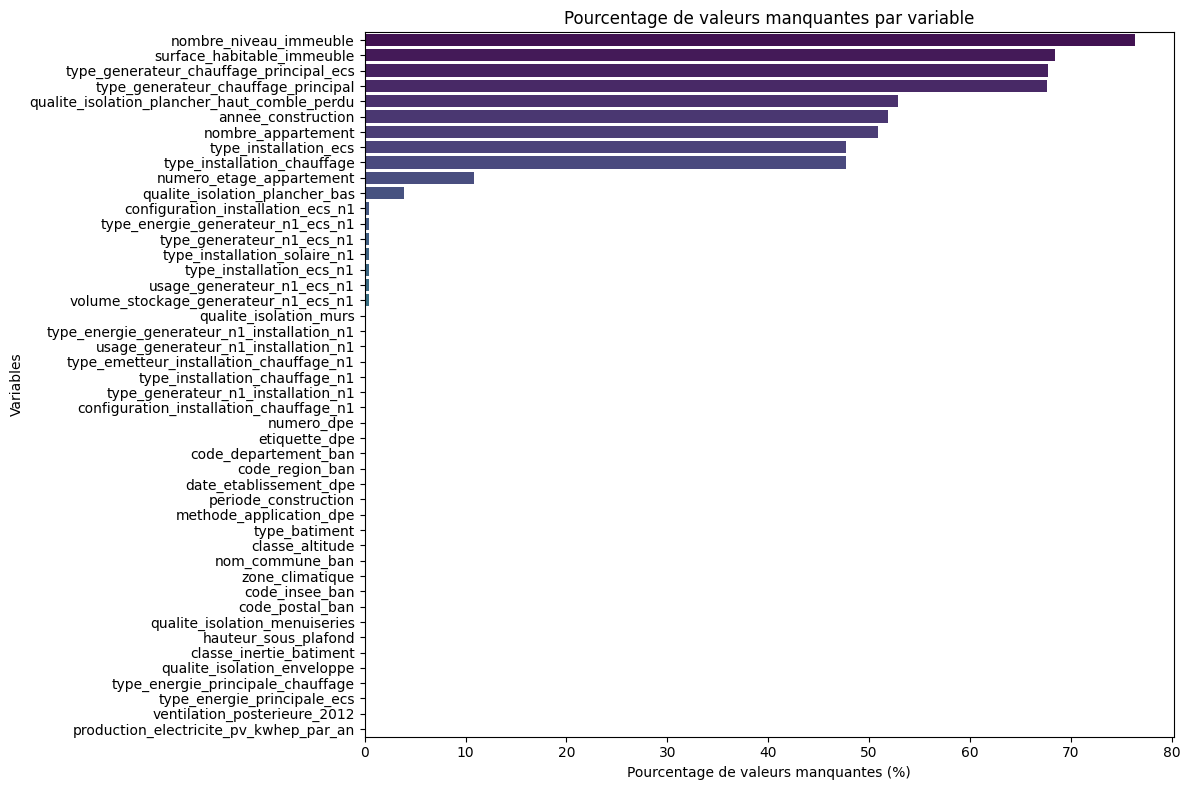

In [5]:
missing = (
    df_data.isnull().sum()
    .reset_index()
    .rename(columns={'index': 'variables', 0: 'counts'})
)
missing['percent'] = (missing['counts'] / len(df_data)) * 100
missing = missing.sort_values('percent', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=missing, x='percent', y='variables', palette='viridis')
plt.xlabel("Pourcentage de valeurs manquantes (%)")
plt.ylabel("Variables")
plt.title("Pourcentage de valeurs manquantes par variable")
plt.tight_layout()
plt.show()

In [6]:
# Variables avec plus de 45% de valeurs manquantes : non récupérables
missing_over_50 = missing[missing['percent'] > 45]
missing_over_50

,variables,counts,percent
15,nombre_niveau_immeuble,44188,76.415453
14,surface_habitable_immeuble,39589,68.462283
38,type_generateur_chauffage_principal_ecs,39175,67.746342
28,type_generateur_chauffage_principal,39130,67.668523
24,qualite_isolation_plancher_haut_comble_perdu,30566,52.858576
13,annee_construction,30028,51.928198
16,nombre_appartement,29440,50.911355
34,type_installation_ecs,27613,47.751876
25,type_installation_chauffage,27613,47.751876


In [7]:
missing_cols_50 = missing_over_50['variables'].tolist()

# Variables sans intérêt pour la modélisation (identifiants, dates, localisation fine)
unecessary_columns = [
    'numero_dpe', 'date_etablissement_dpe', 'code_region_ban', 'code_departement_ban',
    'code_postal_ban', 'code_insee_ban', 'nom_commune_ban', 'numero_etage_appartement',
]

cols_to_drop = missing_cols_50 + unecessary_columns
print(f"Colonnes supprimées ({len(cols_to_drop)}) : {cols_to_drop}")

df_data_clean1 = df_data.drop(columns=cols_to_drop)
print(f"\nDataset après suppression : {df_data_clean1.shape[0]:,} lignes × {df_data_clean1.shape[1]} colonnes")

Colonnes supprimées (17) : ['nombre_niveau_immeuble', 'surface_habitable_immeuble', 'type_generateur_chauffage_principal_ecs', 'type_generateur_chauffage_principal', 'qualite_isolation_plancher_haut_comble_perdu', 'annee_construction', 'nombre_appartement', 'type_installation_ecs', 'type_installation_chauffage', 'numero_dpe', 'date_etablissement_dpe', 'code_region_ban', 'code_departement_ban', 'code_postal_ban', 'code_insee_ban', 'nom_commune_ban', 'numero_etage_appartement']

Dataset après suppression : 57,826 lignes × 29 colonnes


In [8]:
# Vérification des valeurs manquantes restantes
missing_restant = (
    df_data_clean1.isnull().sum()
    .reset_index()
    .rename(columns={'index': 'variables', 0: 'counts'})
)
missing_restant['percent'] = (missing_restant['counts'] / len(df_data_clean1)) * 100
missing_restant[missing_restant['percent'] > 0]

,variables,counts,percent
9,qualite_isolation_murs,26,0.044962
11,qualite_isolation_plancher_bas,2228,3.852938
12,type_installation_chauffage_n1,26,0.044962
13,configuration_installation_chauffage_n1,26,0.044962
14,type_generateur_n1_installation_n1,26,0.044962
16,type_energie_generateur_n1_installation_n1,26,0.044962
17,type_emetteur_installation_chauffage_n1,26,0.044962
18,usage_generateur_n1_installation_n1,26,0.044962
19,type_installation_ecs_n1,227,0.392557
20,configuration_installation_ecs_n1,227,0.392557


In [9]:
# Les valeurs manquantes restantes sont peu nombreuses : suppression des lignes concernées
df_data_clean = df_data_clean1.dropna().copy()
print(f"Dataset final : {df_data_clean.shape[0]:,} lignes × {df_data_clean.shape[1]} colonnes")

Dataset final : 55,357 lignes × 29 colonnes


**Interprétation :** les variables ayant plus de 45 % de valeurs manquantes apportent trop peu d'information exploitable et sont supprimées. Les quelques valeurs manquantes restantes sont marginales : les lignes concernées sont retirées sans impact significatif sur la taille du jeu de données.

## 3. Analyse des variables catégorielles

In [10]:
quant_cols = [
    "hauteur_sous_plafond",
    "volume_stockage_generateur_n1_ecs_n1",
    "ventilation_posterieure_2012",
    "production_electricite_pv_kwhep_par_an",
]

qual_and_target = quant_cols + ["etiquette_dpe"]
qual_cols = [c for c in df_data_clean.columns if c not in qual_and_target]

print(f"Dataset : {df_data_clean.shape[0]:,} lignes, {df_data_clean.shape[1]} colonnes")
print(f"  Quantitatives : {len(quant_cols)}")
print(f"  Qualitatives  : {len(qual_cols)}")

Dataset : 55,357 lignes, 29 colonnes
  Quantitatives : 4
  Qualitatives  : 24


### 3.1 Analyse des redondances entre variables

Pour repérer les variables potentiellement redondantes, on regroupe les variables qualitatives par cardinalité (nombre de modalités), puis on compare les paires de variables de même cardinalité via des tableaux croisés.

In [11]:
cardinalities = df_data_clean[qual_cols].nunique().sort_values()

lots = defaultdict(list)
for col in qual_cols:
    k = df_data_clean[col].nunique()
    lots[k].append(col)
lots = dict(lots)

lots_table = pd.DataFrame(
    [(k, v) for k, cols in lots.items() for v in cols],
    columns=['cardinalité', 'variable']
)
lots_table

,cardinalité,variable
0,8,zone_climatique
1,3,classe_altitude
2,3,type_batiment
3,3,type_installation_ecs_n1
4,3,configuration_installation_ecs_n1
5,4,methode_application_dpe
6,4,classe_inertie_batiment
7,4,qualite_isolation_enveloppe
8,4,qualite_isolation_murs
9,4,qualite_isolation_menuiseries


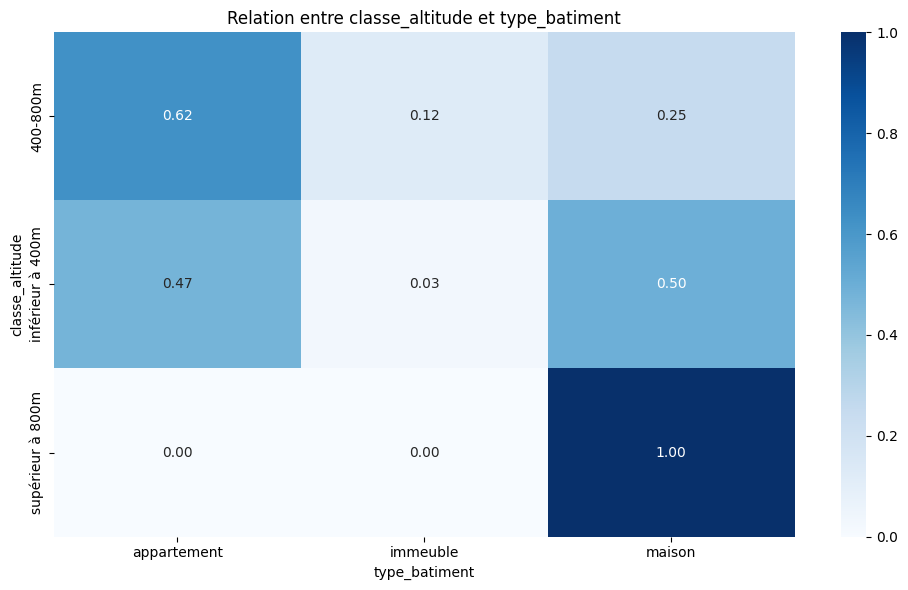

C:\Users\berul\AppData\Local\Temp\ipykernel_136668\1722847964.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


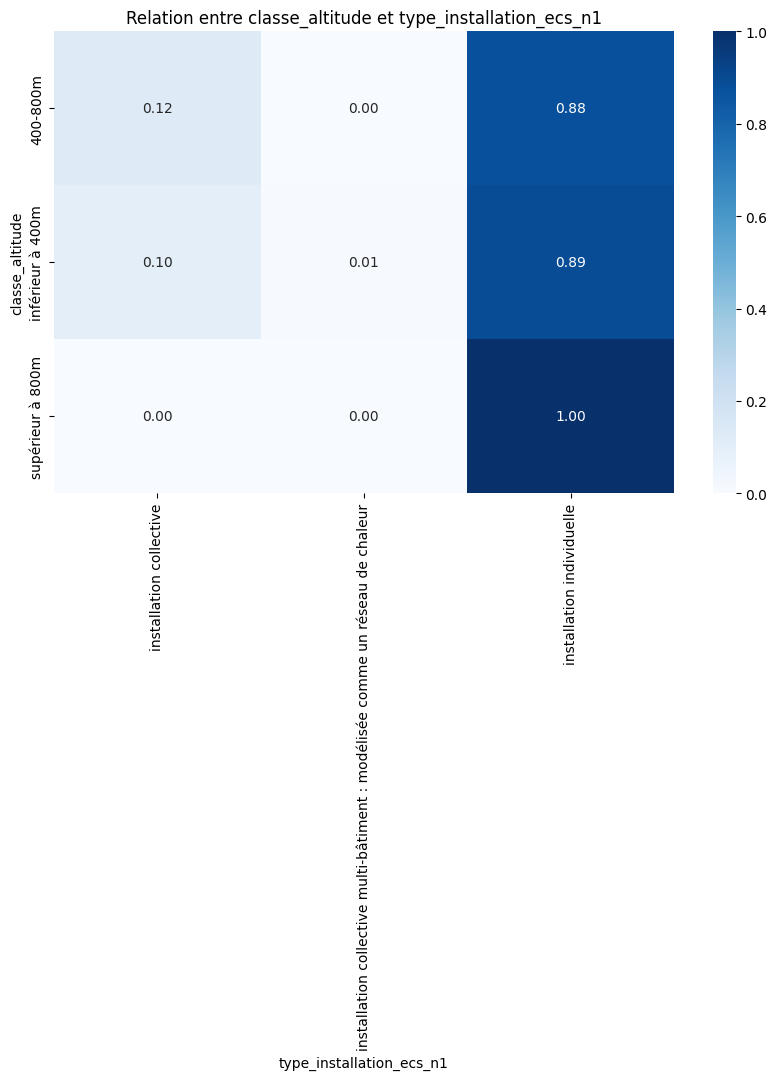

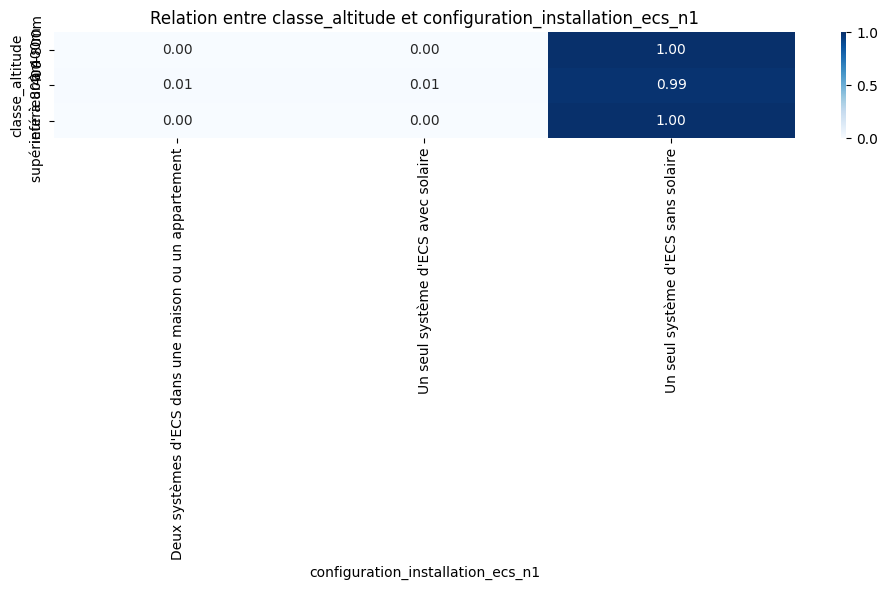

C:\Users\berul\AppData\Local\Temp\ipykernel_136668\1722847964.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


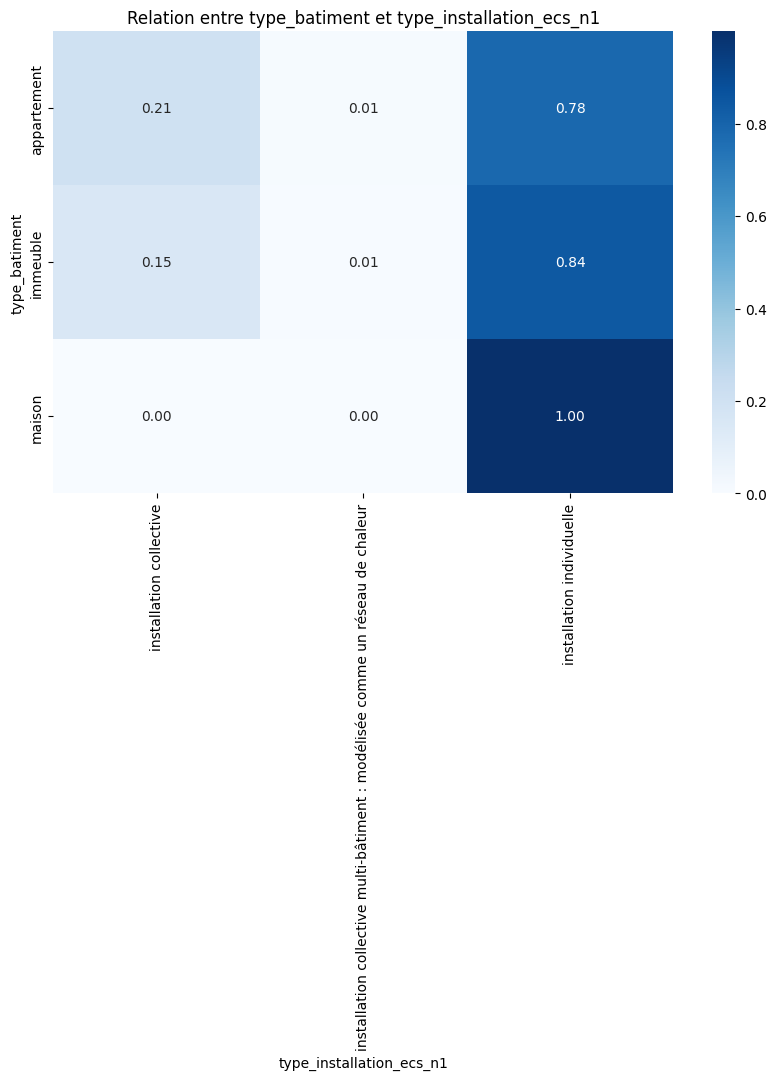

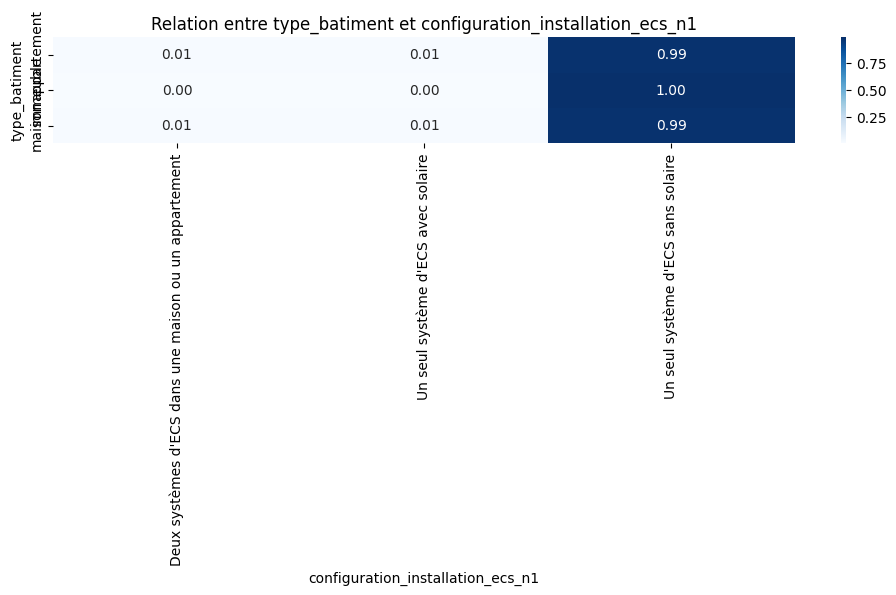

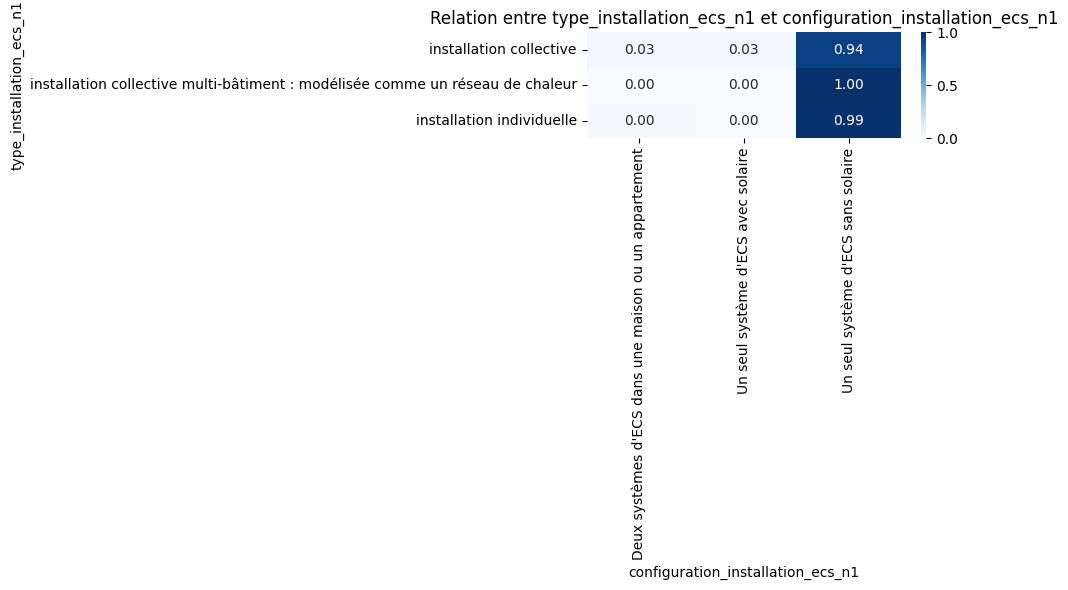

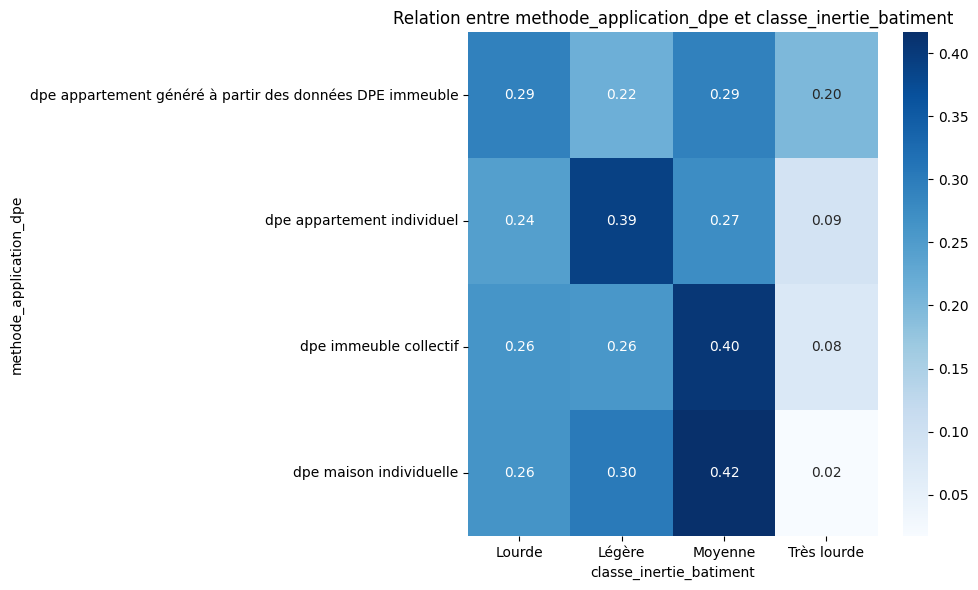

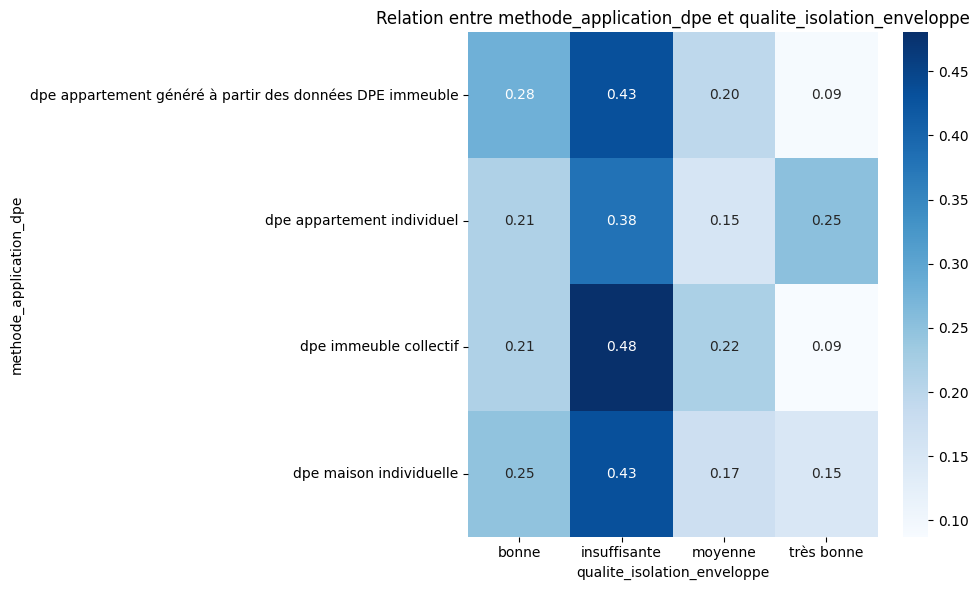

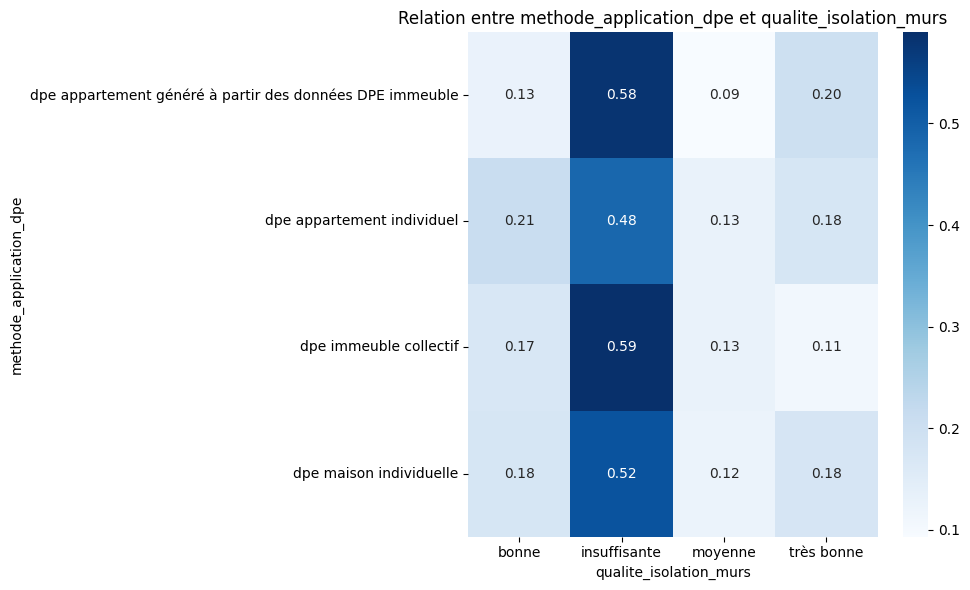

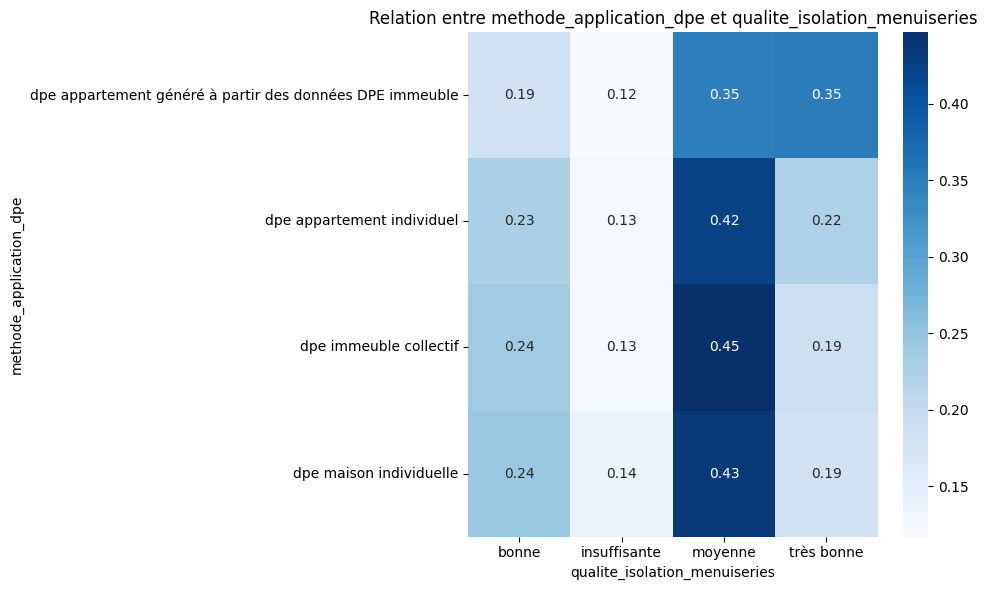

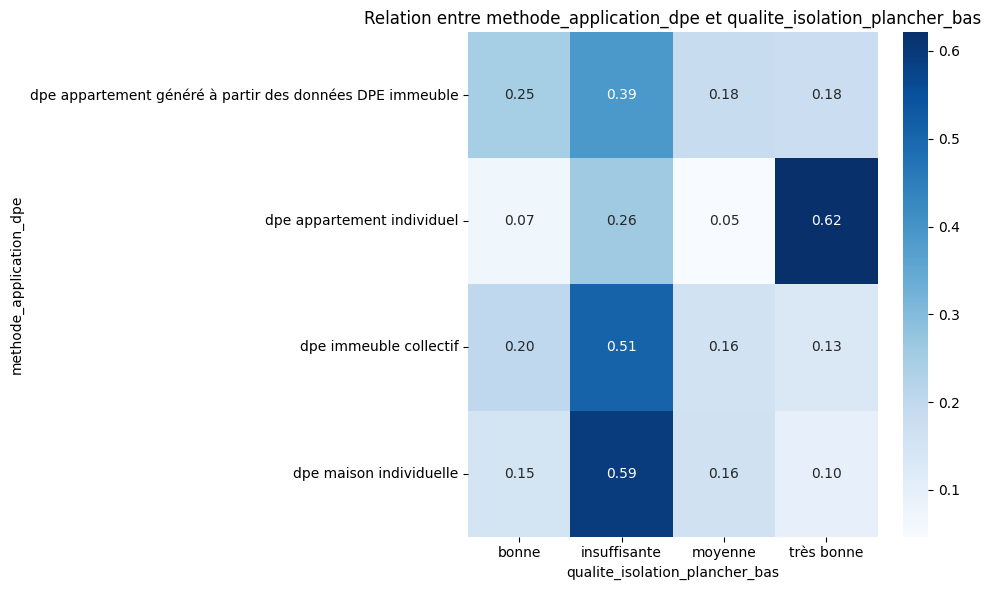

C:\Users\berul\AppData\Local\Temp\ipykernel_136668\1722847964.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


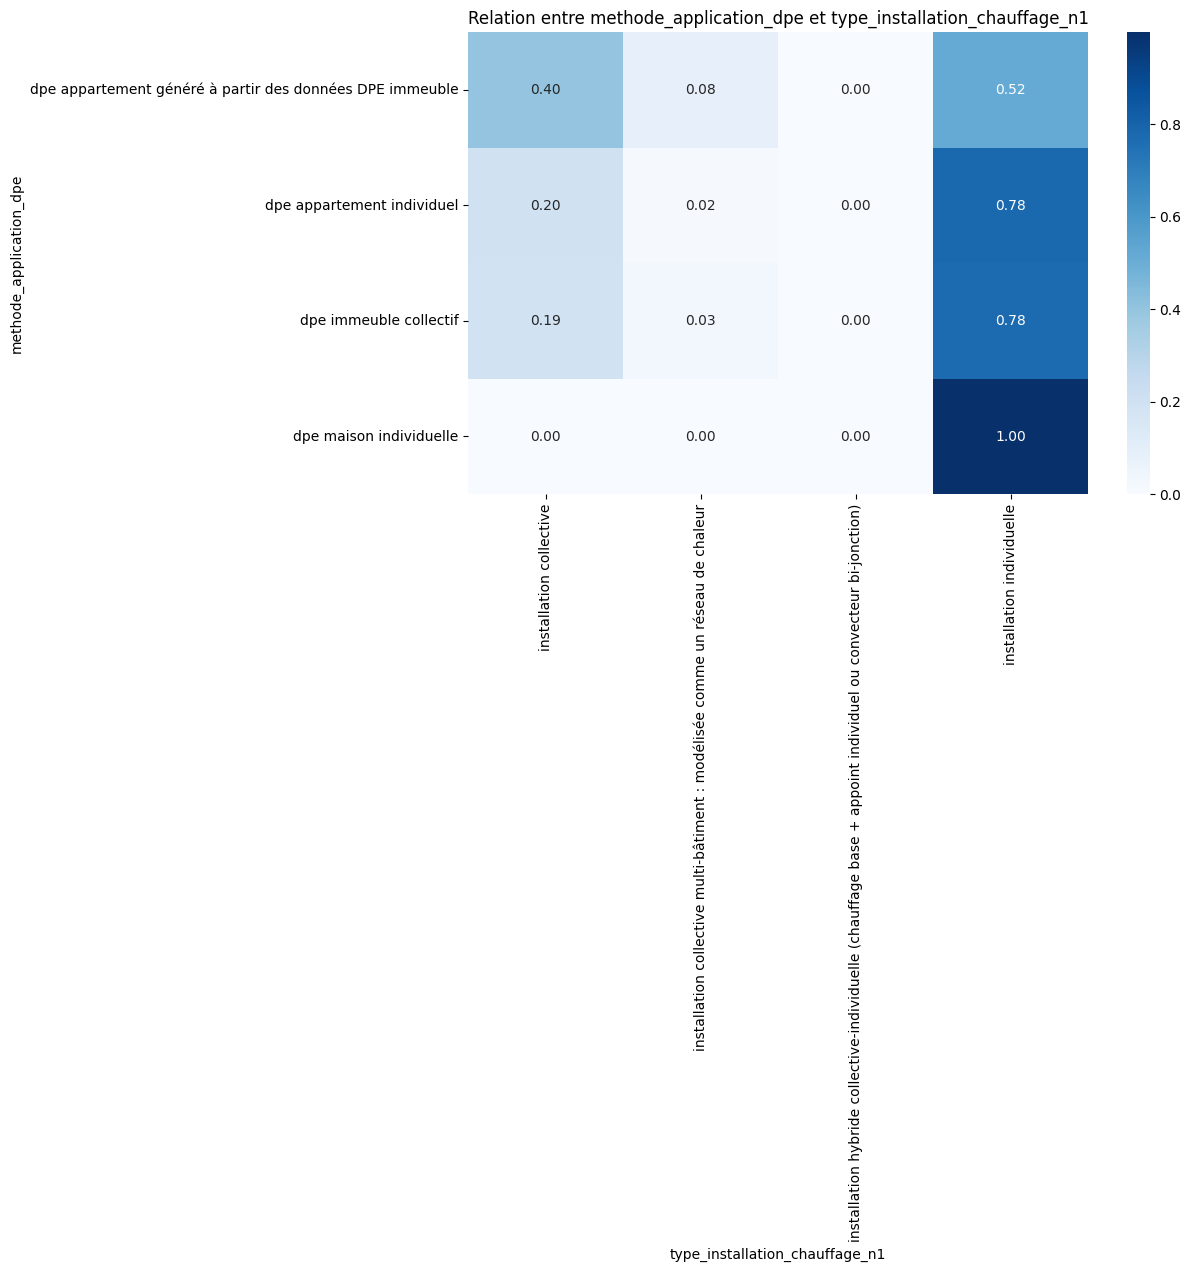

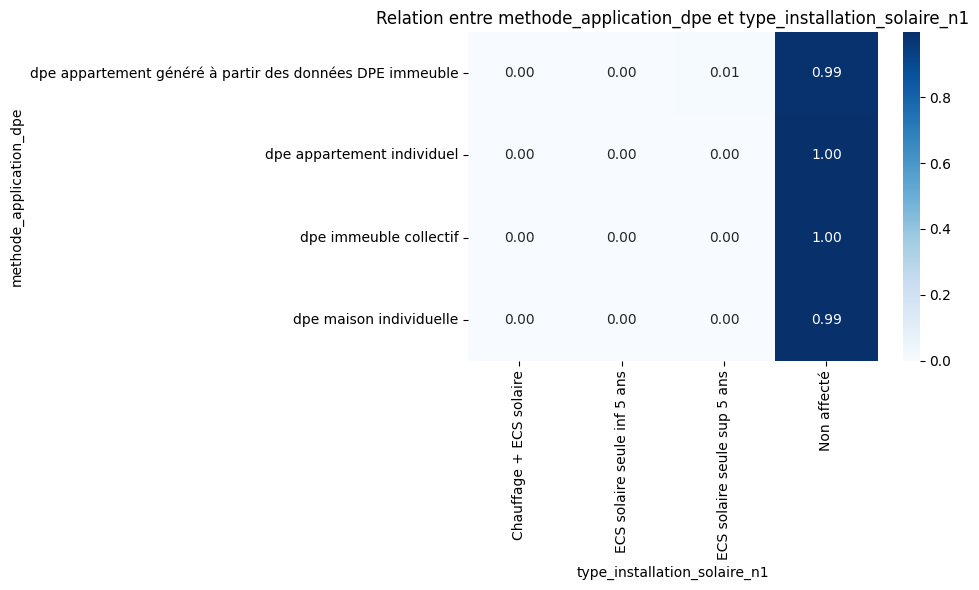

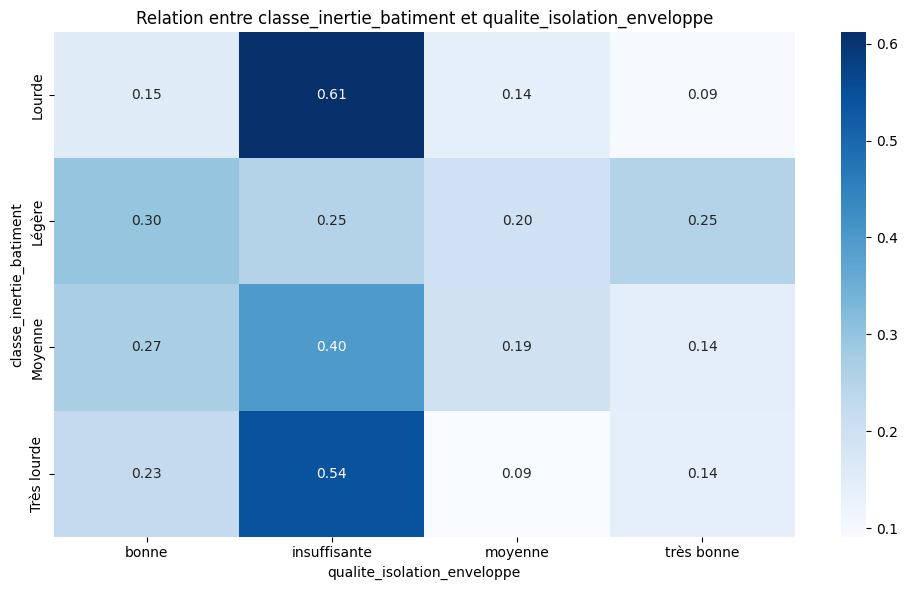

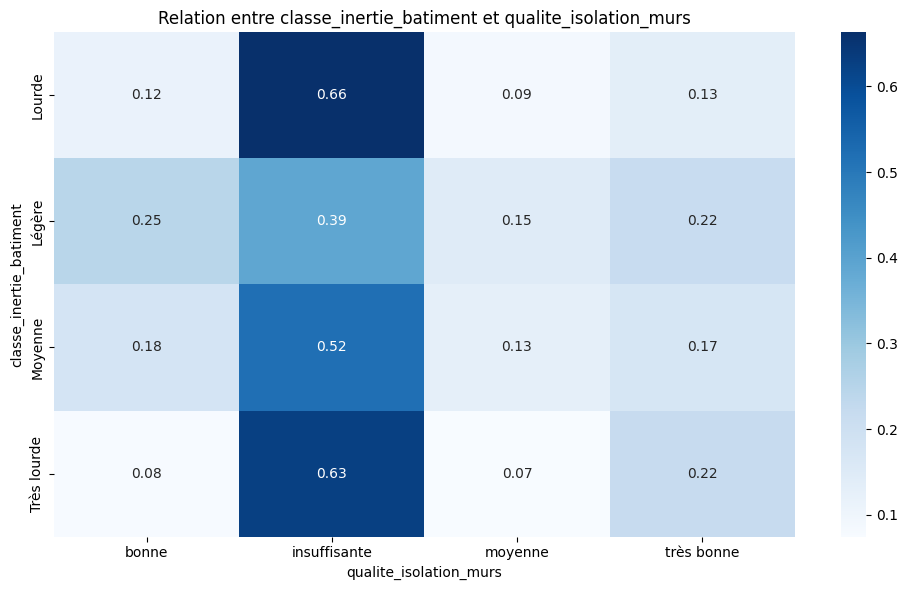

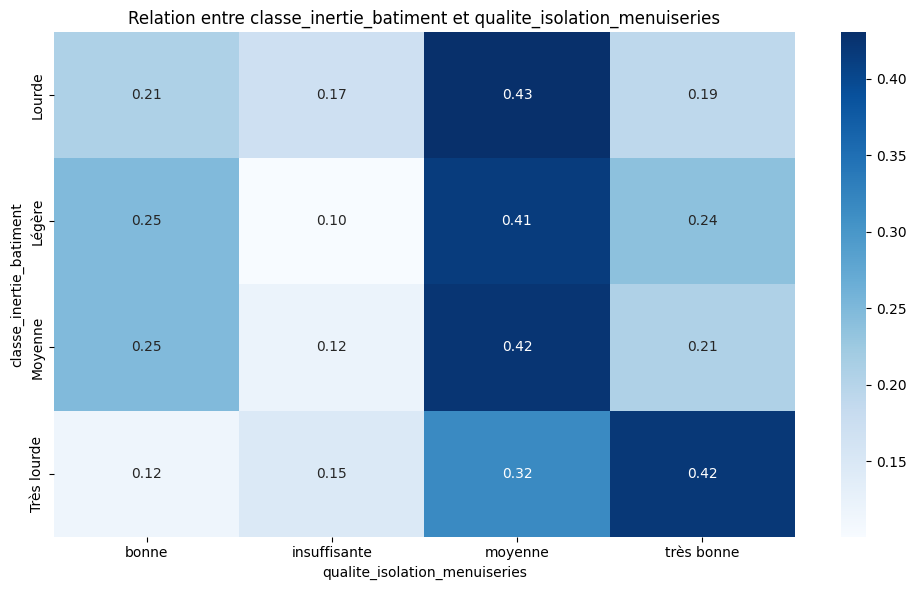

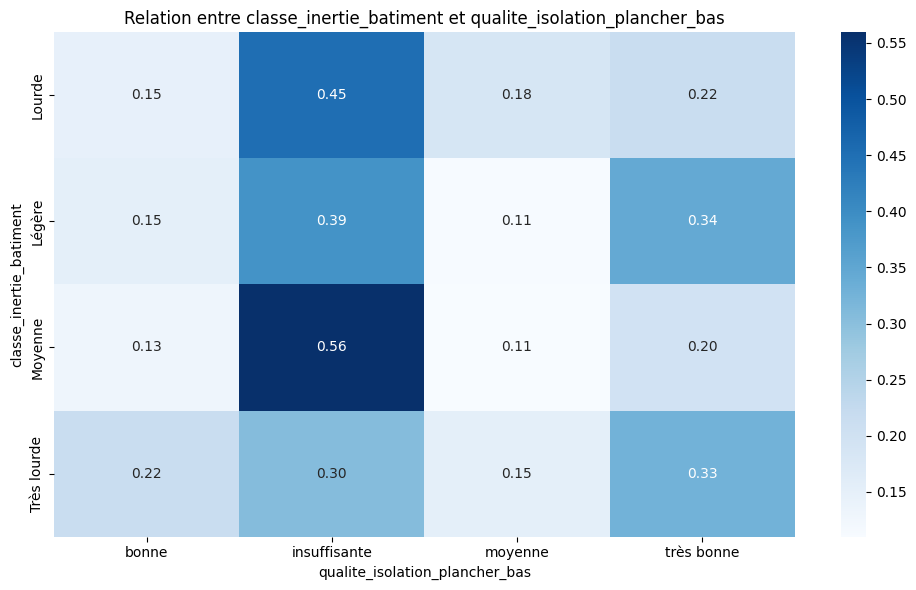

C:\Users\berul\AppData\Local\Temp\ipykernel_136668\1722847964.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


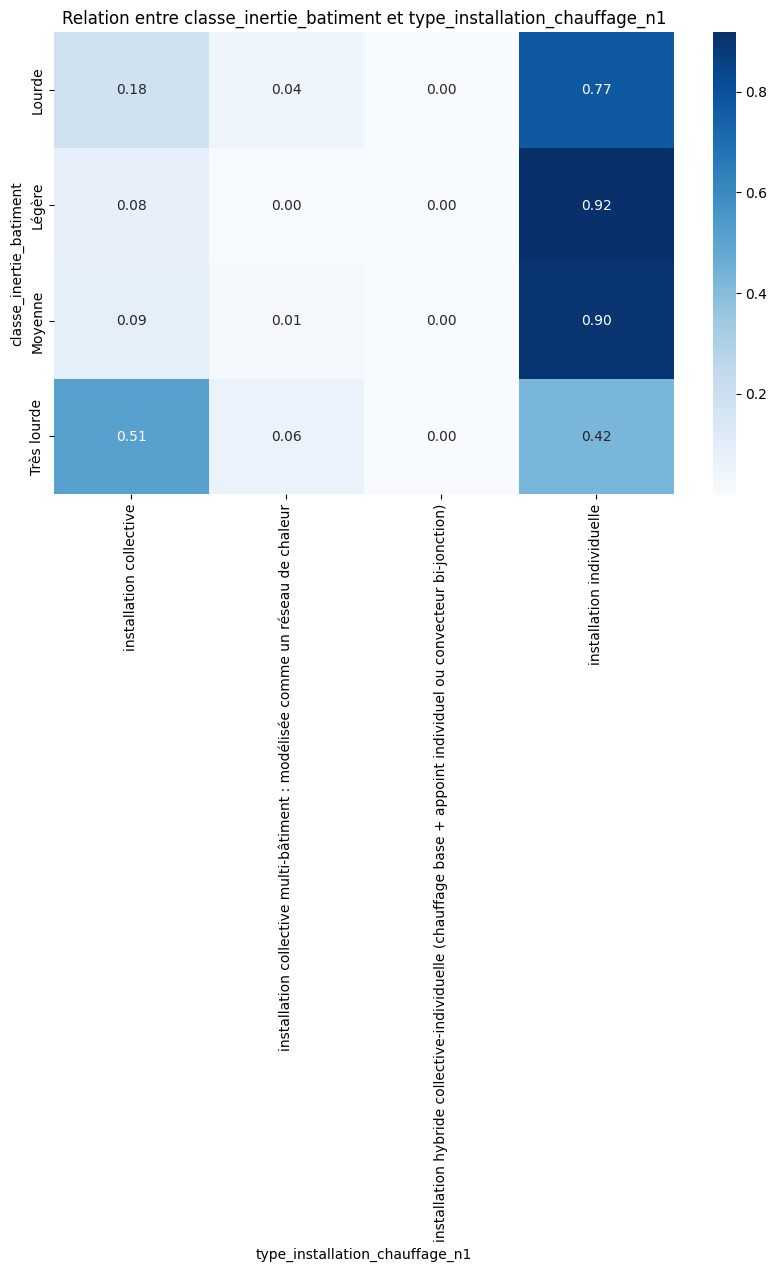

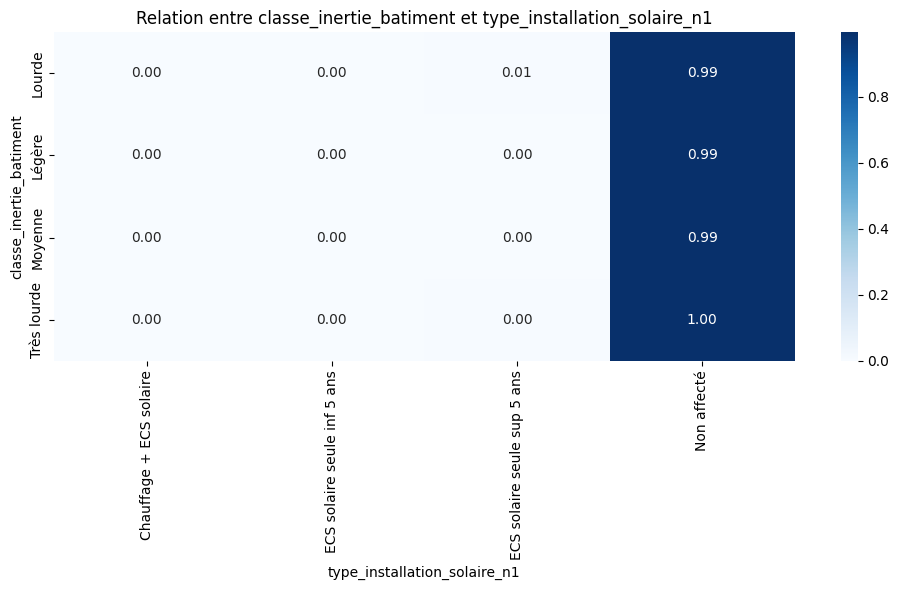

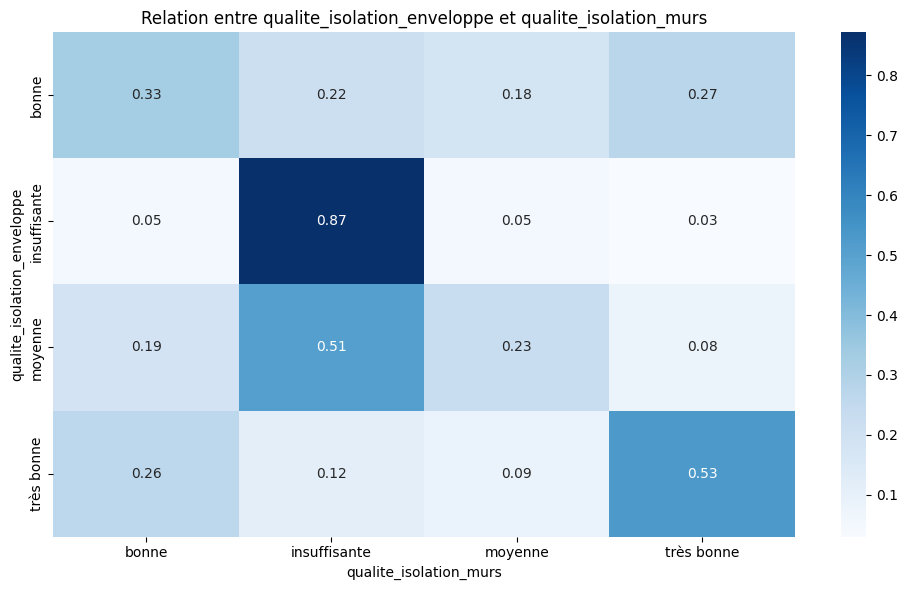

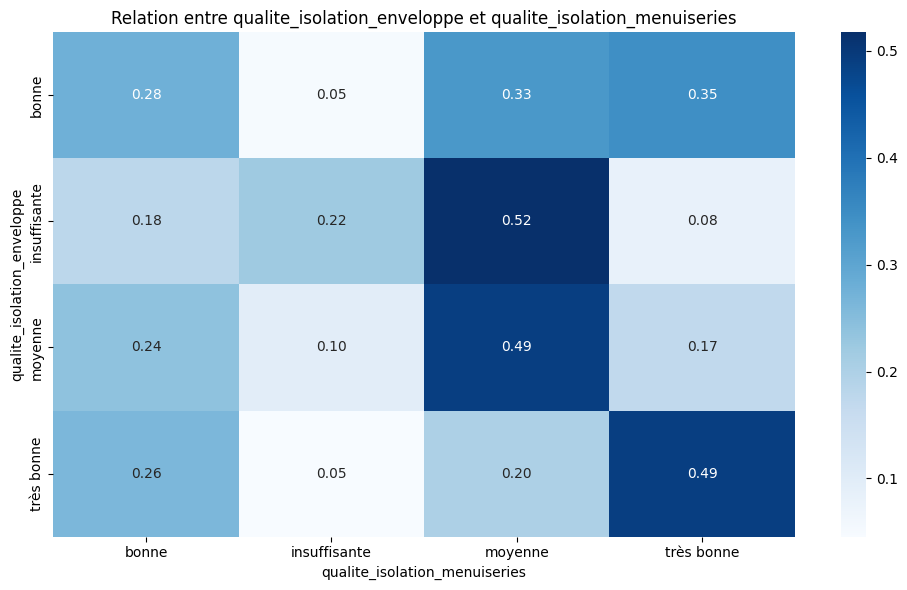

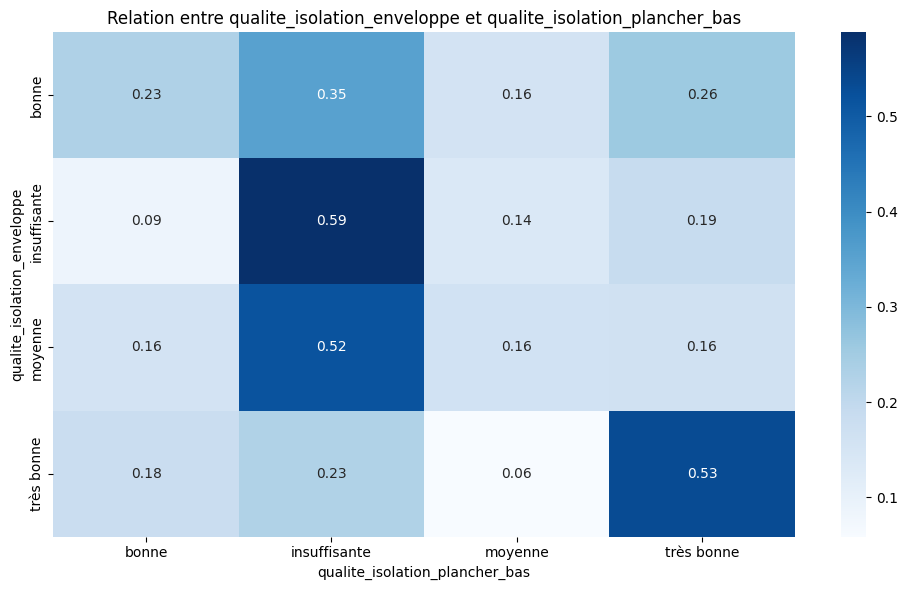

C:\Users\berul\AppData\Local\Temp\ipykernel_136668\1722847964.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


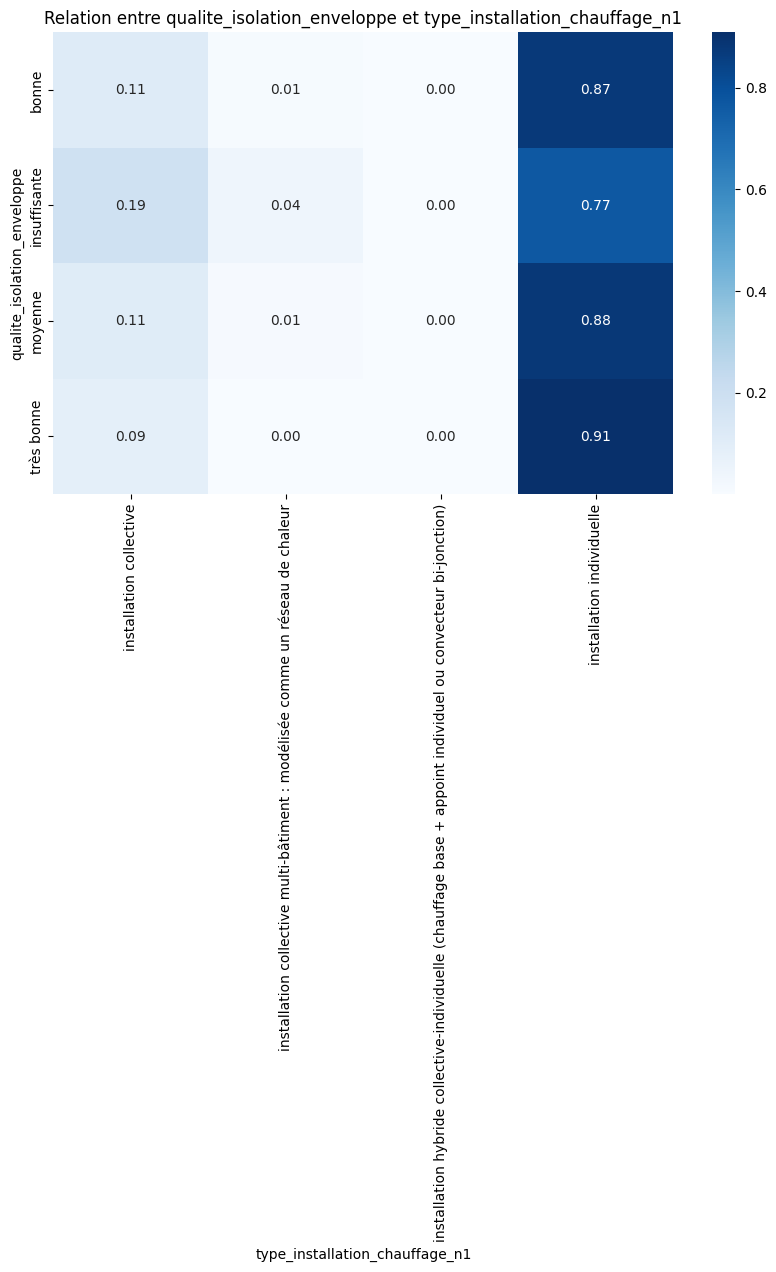

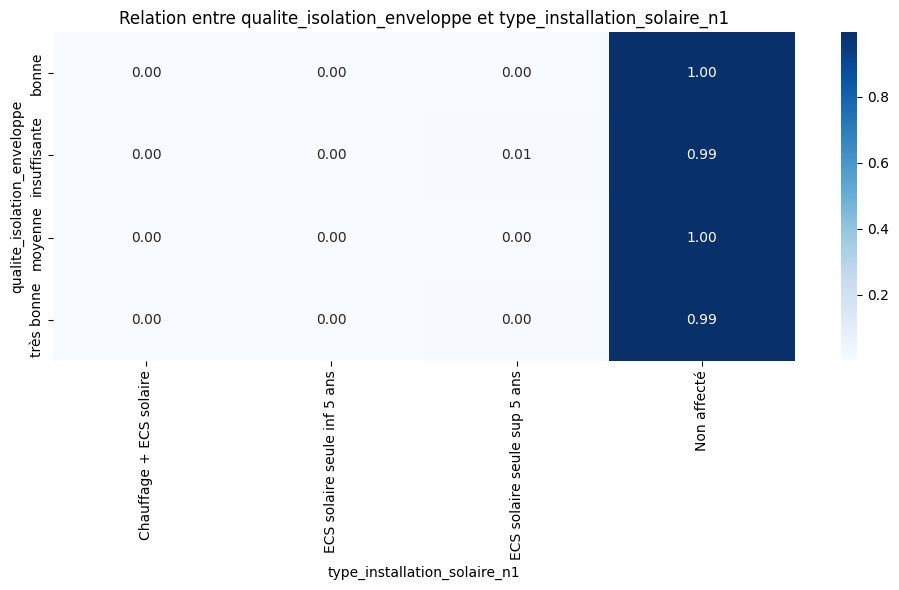

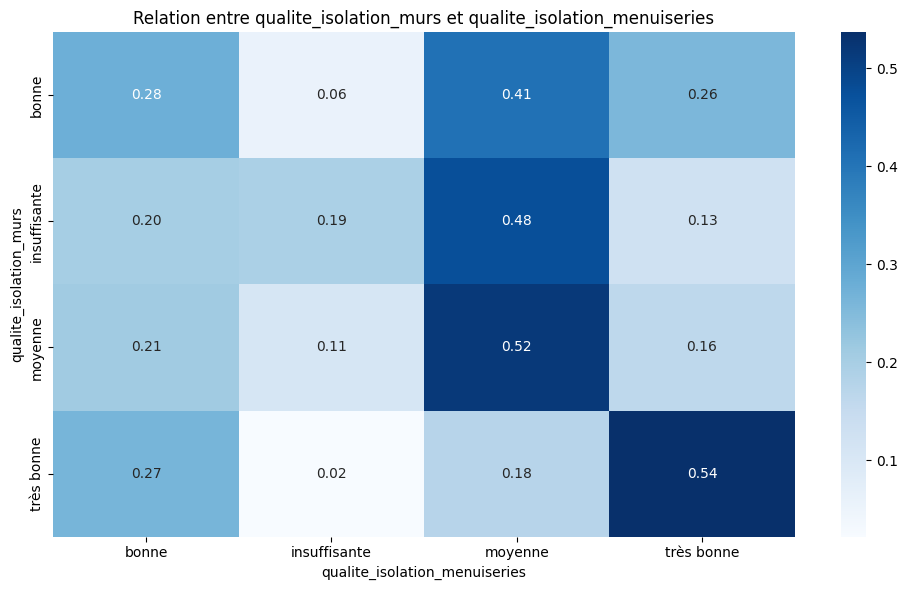

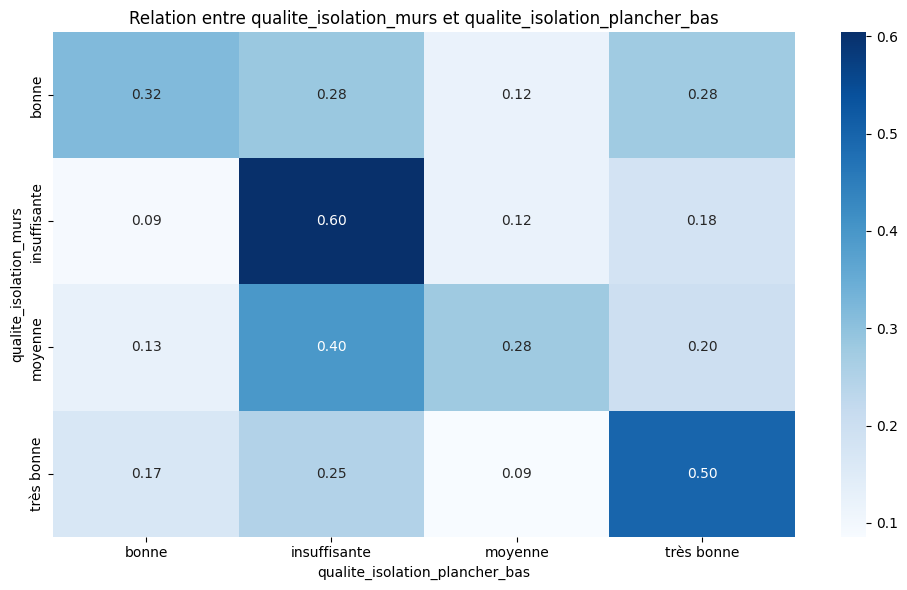

C:\Users\berul\AppData\Local\Temp\ipykernel_136668\1722847964.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


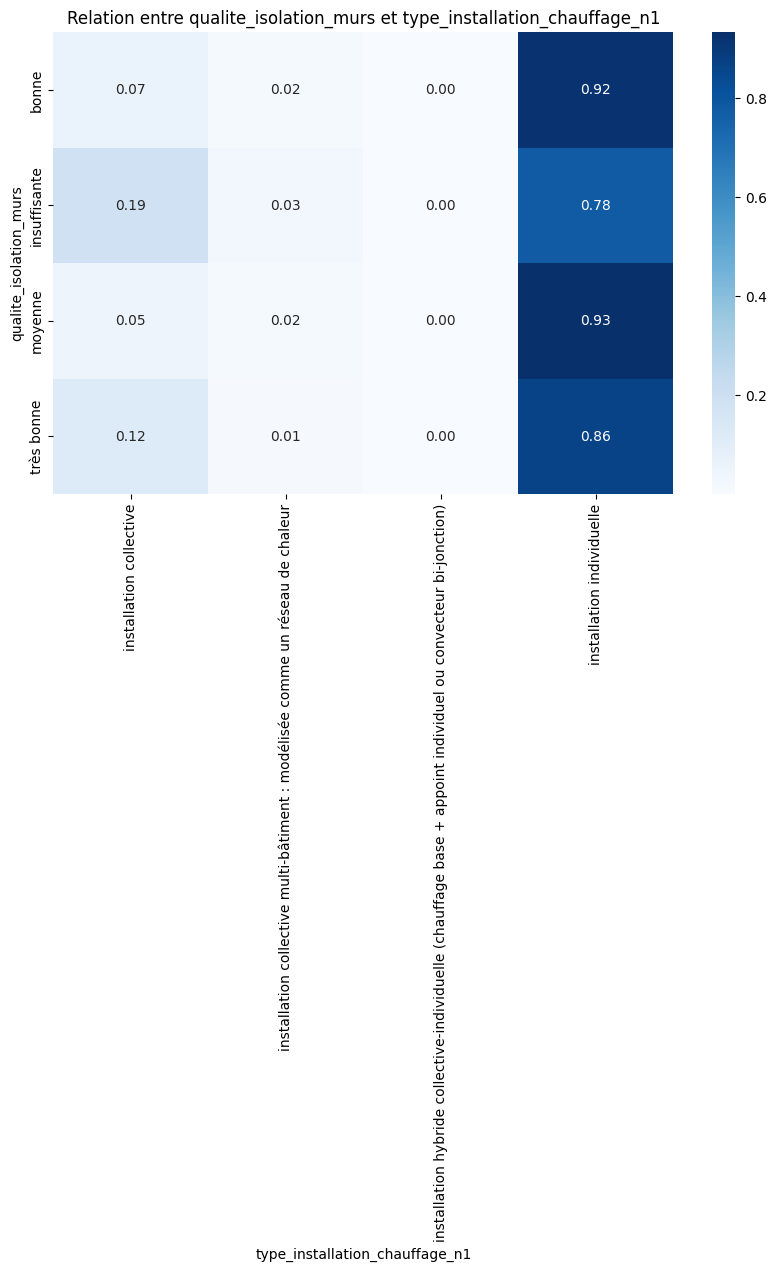

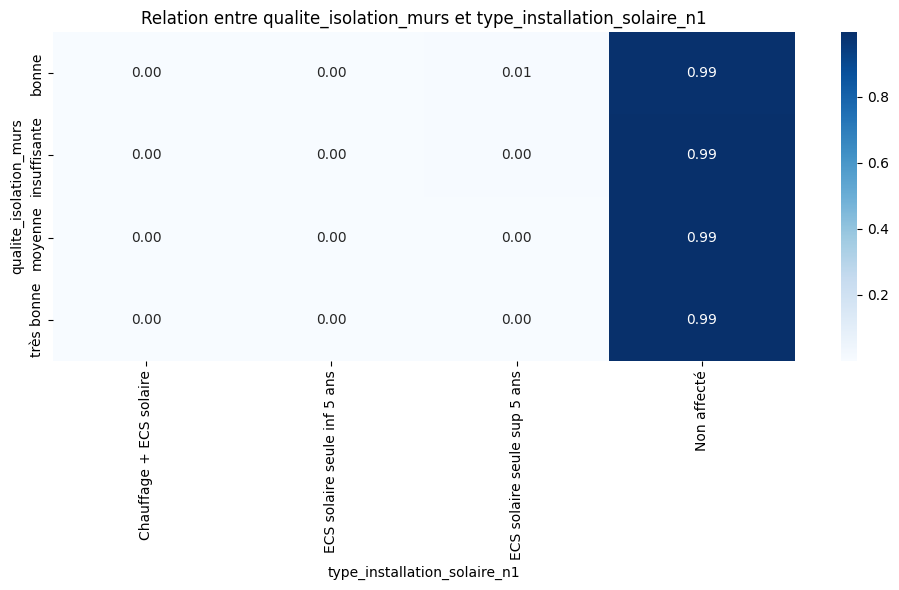

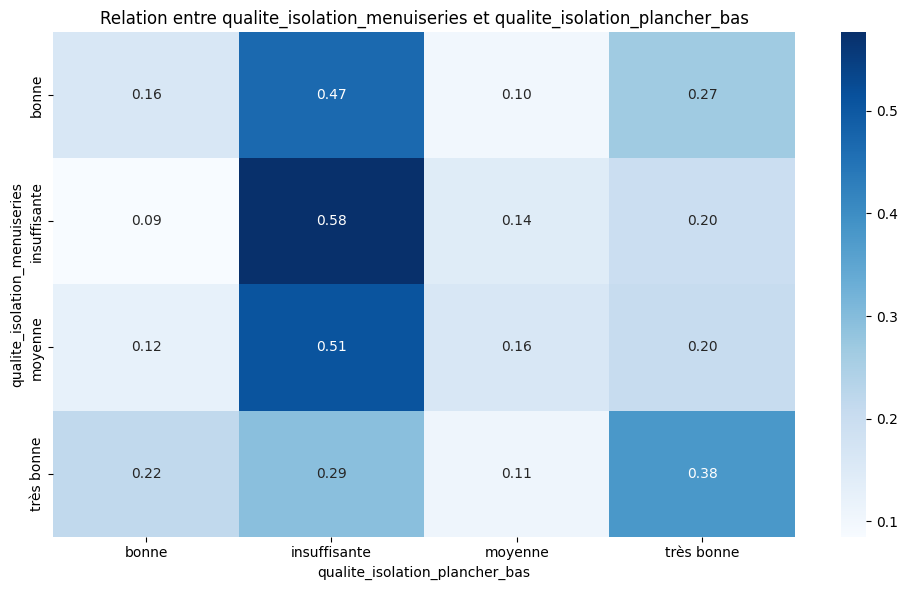

C:\Users\berul\AppData\Local\Temp\ipykernel_136668\1722847964.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


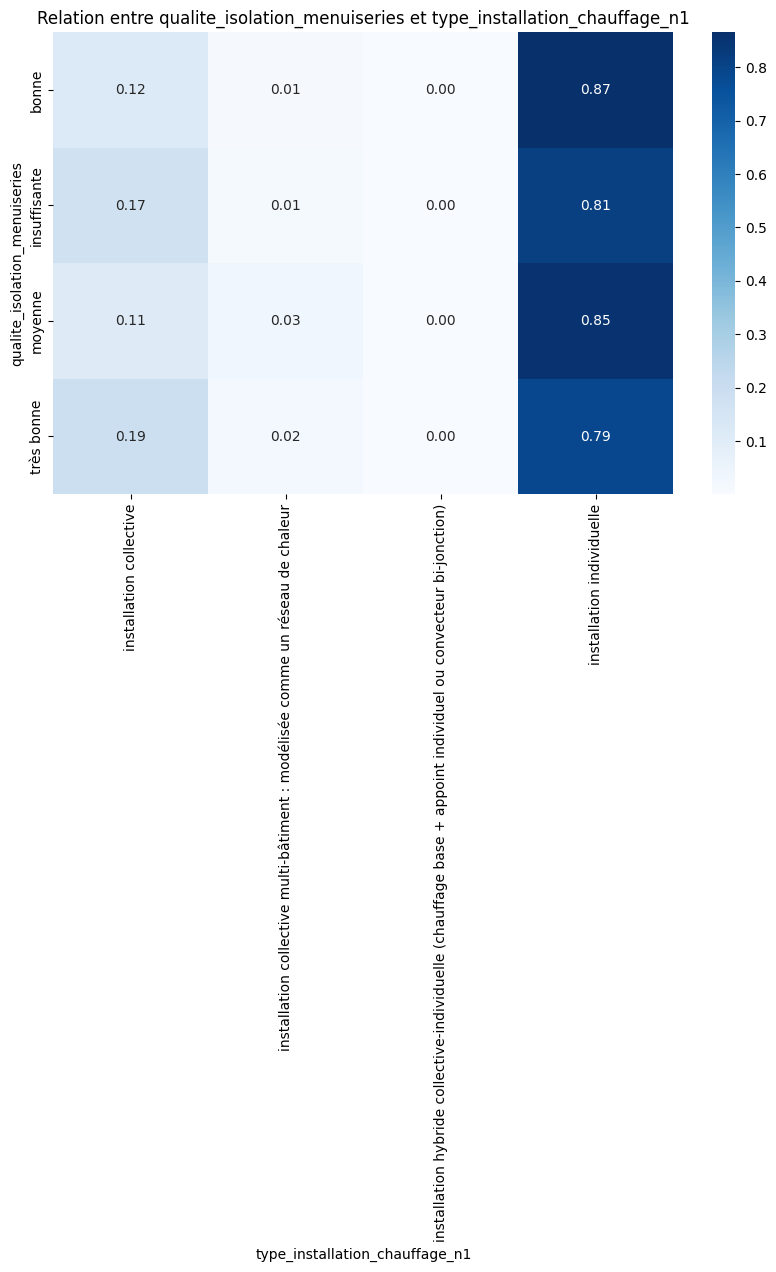

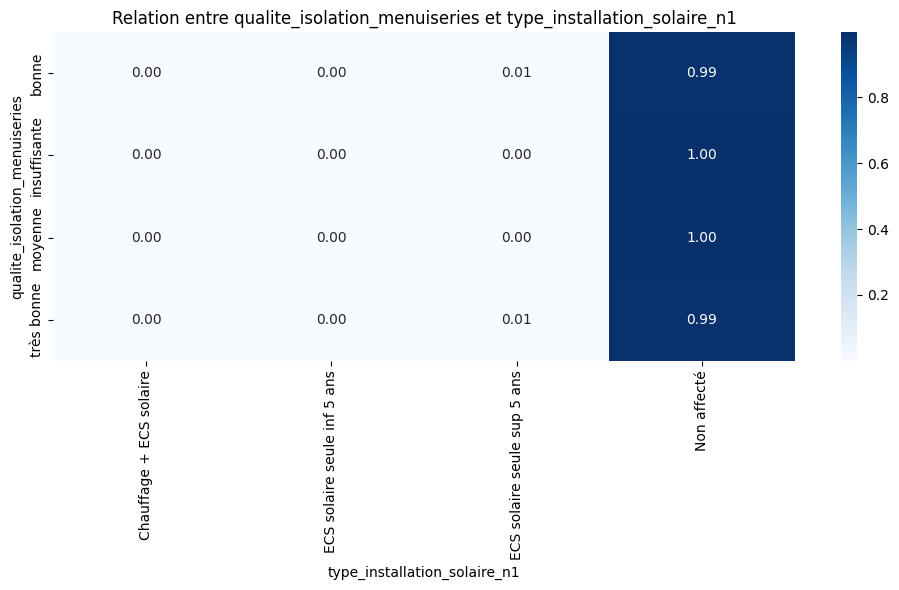

C:\Users\berul\AppData\Local\Temp\ipykernel_136668\1722847964.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


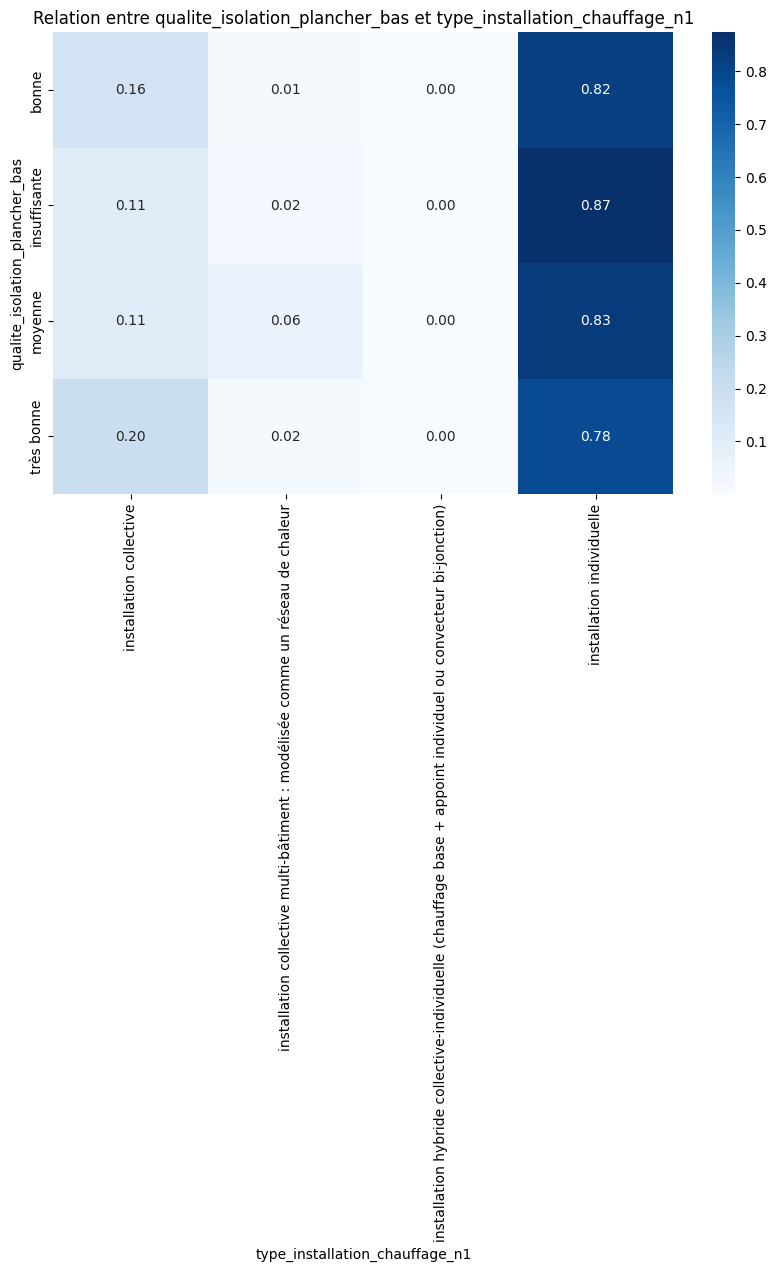

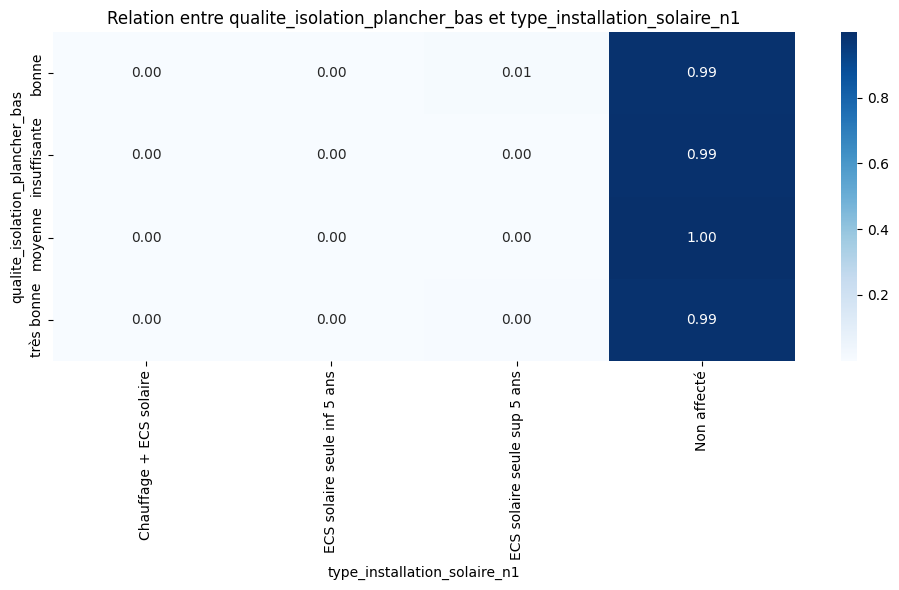

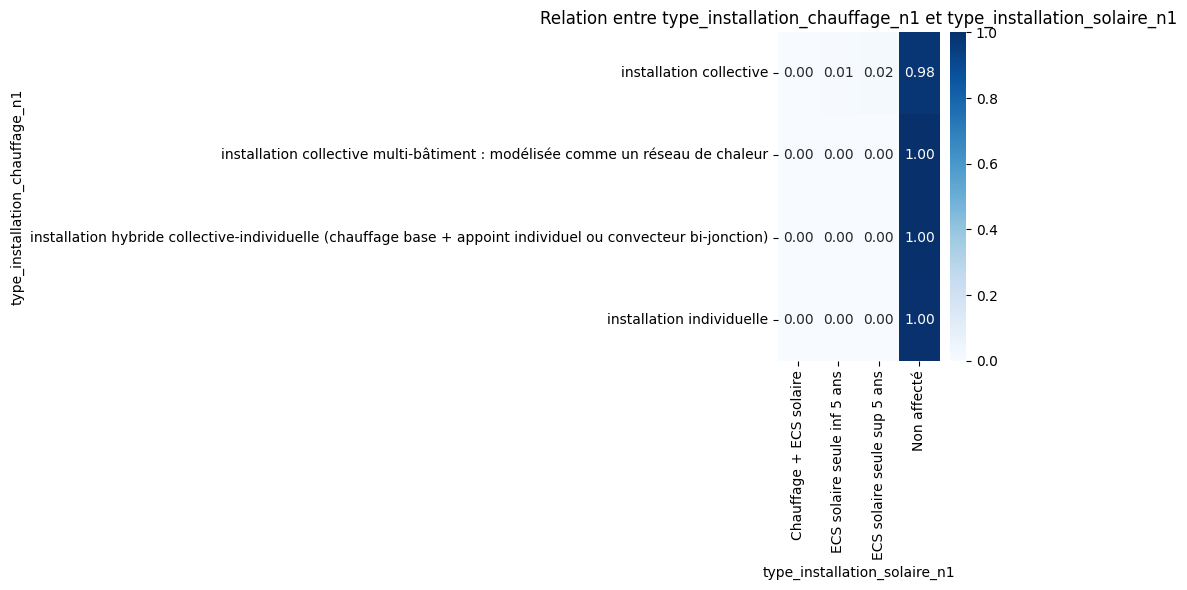

C:\Users\berul\AppData\Local\Temp\ipykernel_136668\1722847964.py:14: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


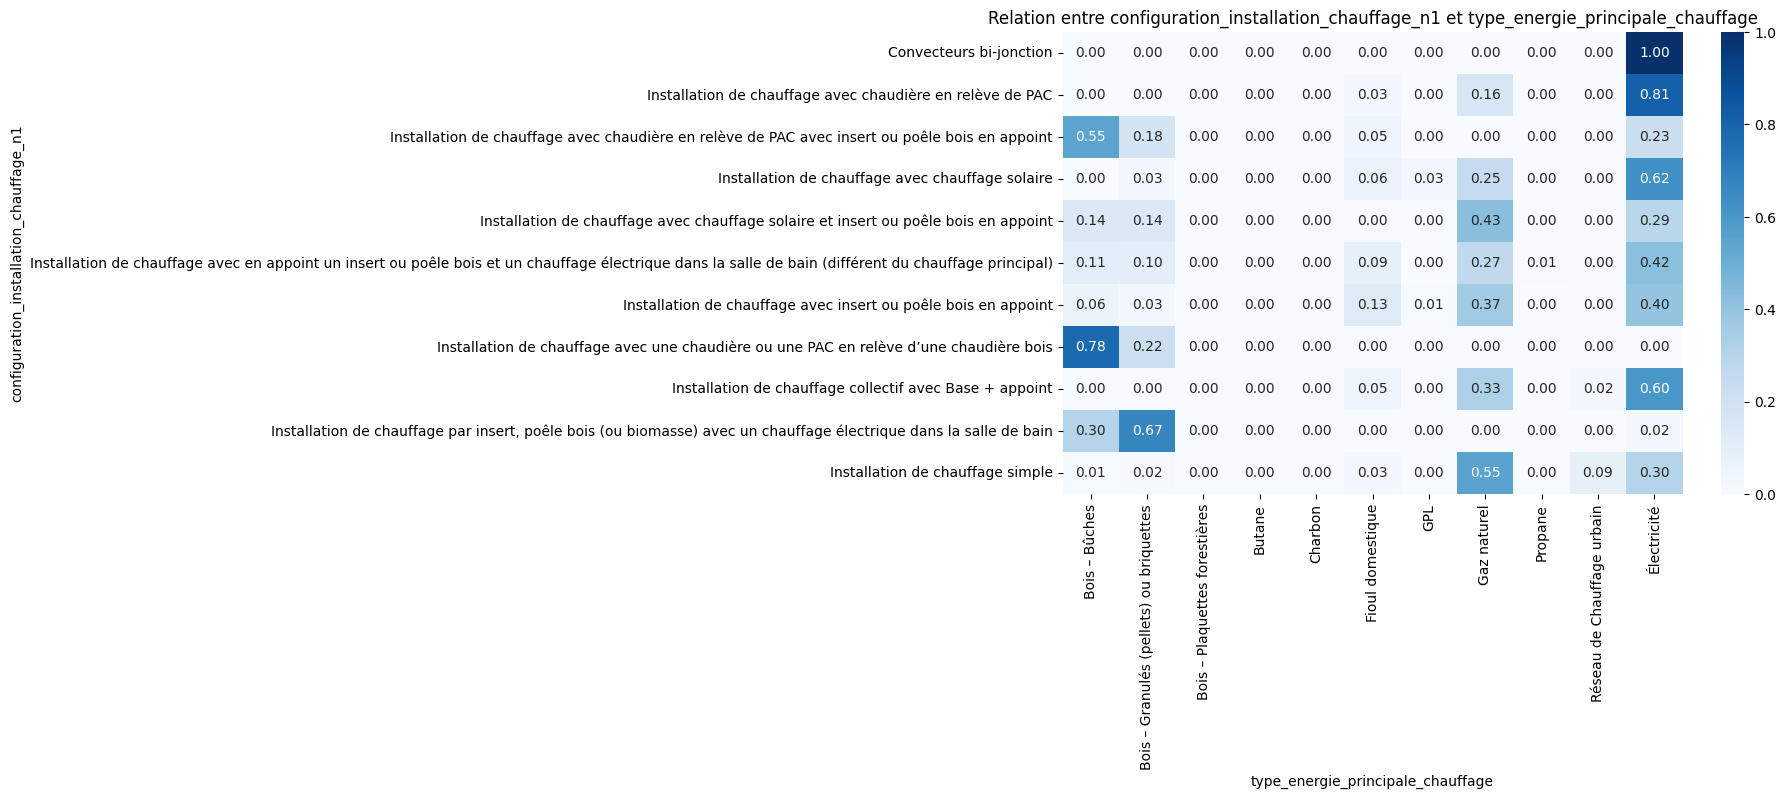

C:\Users\berul\AppData\Local\Temp\ipykernel_136668\1722847964.py:14: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


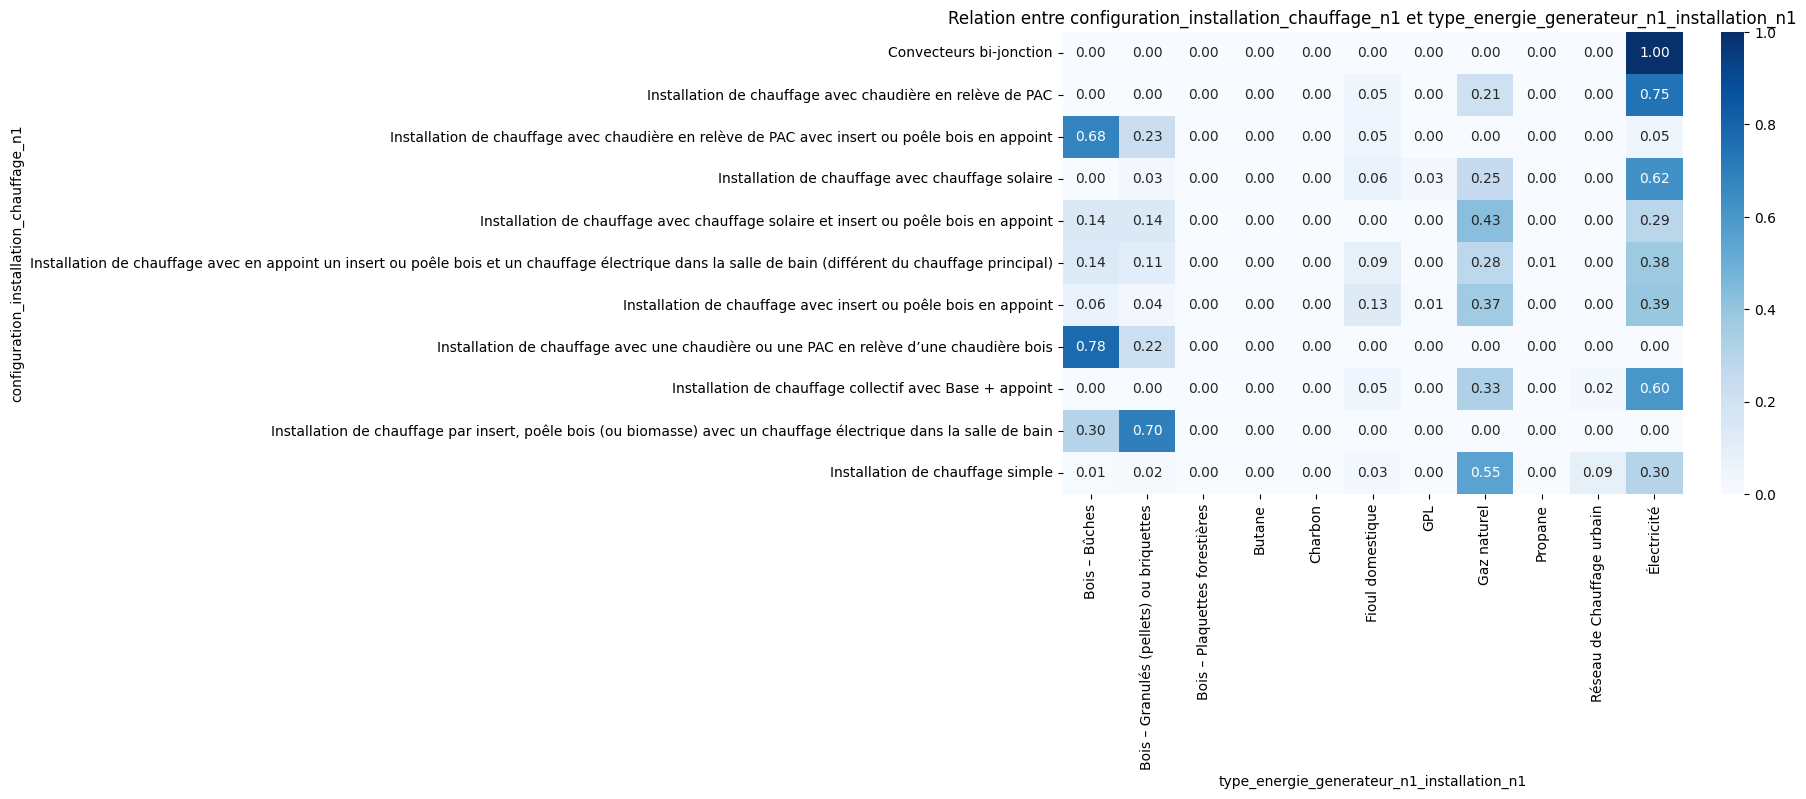

C:\Users\berul\AppData\Local\Temp\ipykernel_136668\1722847964.py:14: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


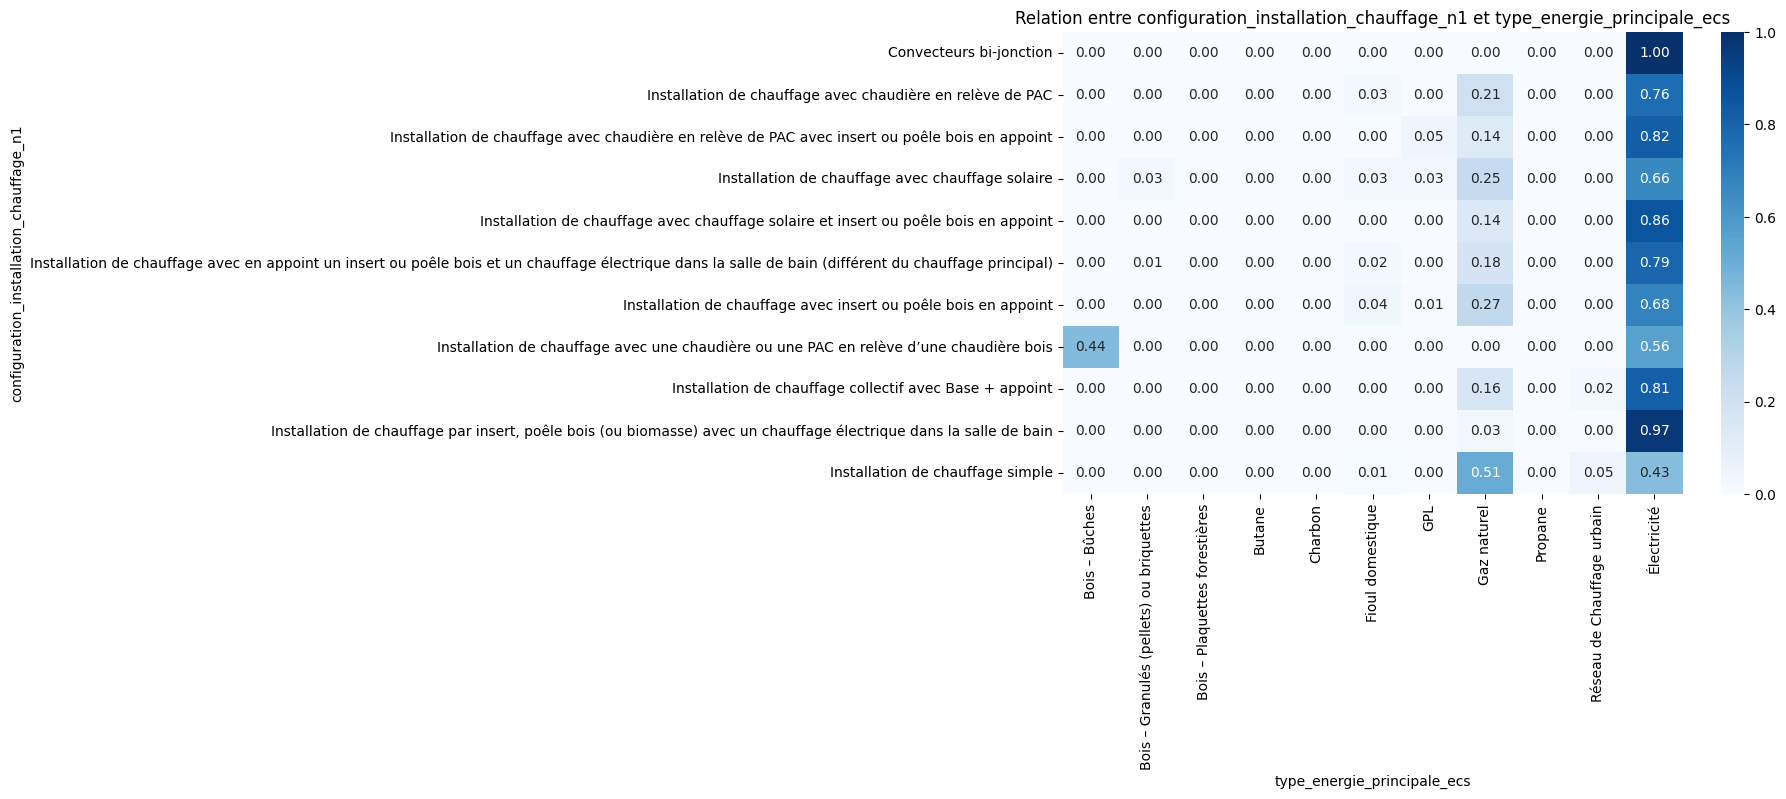

C:\Users\berul\AppData\Local\Temp\ipykernel_136668\1722847964.py:14: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


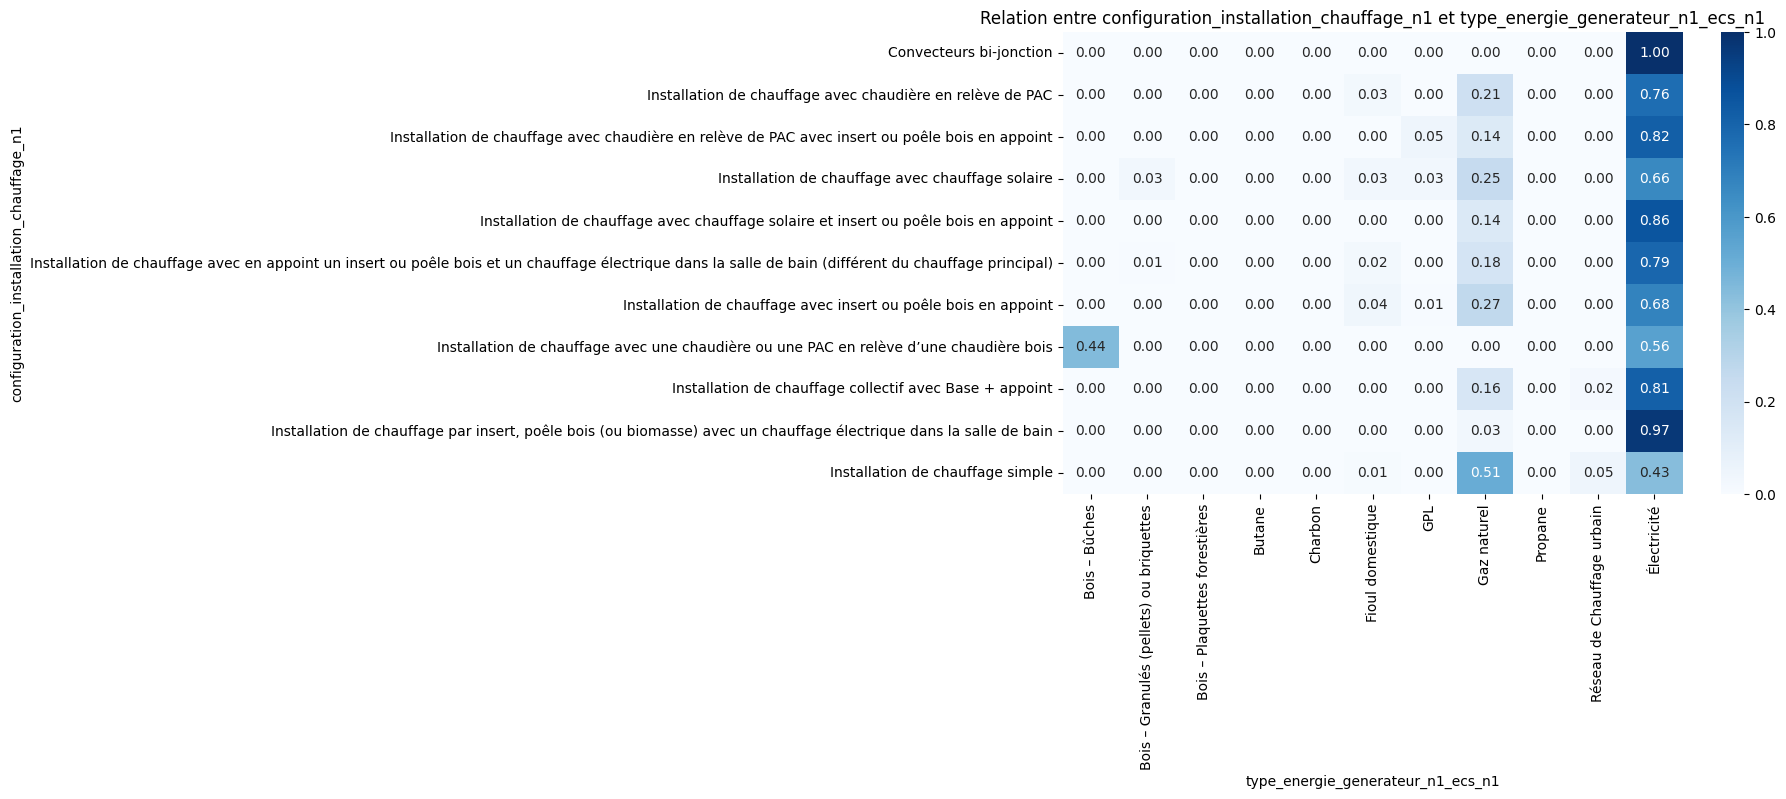

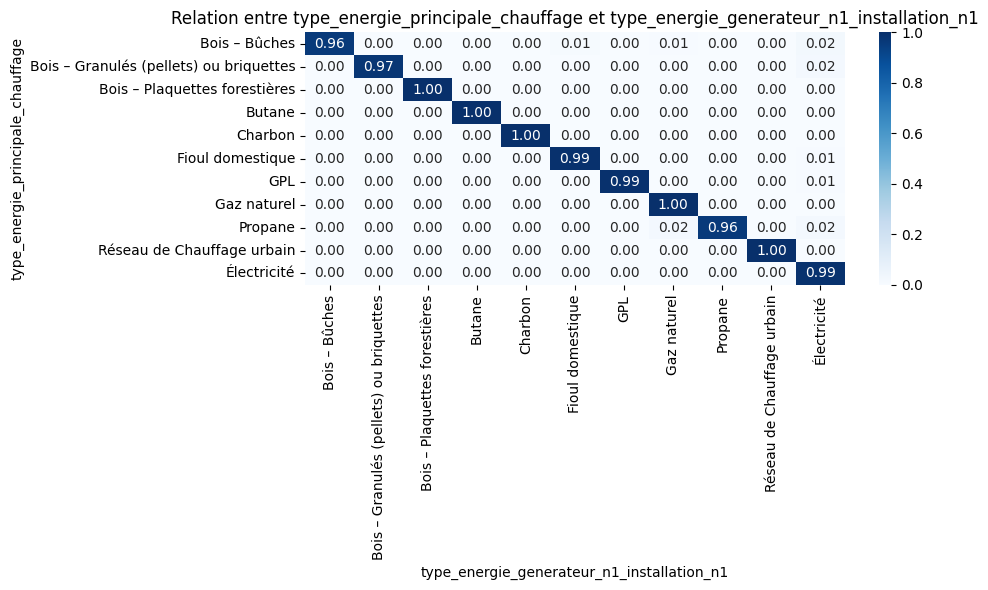

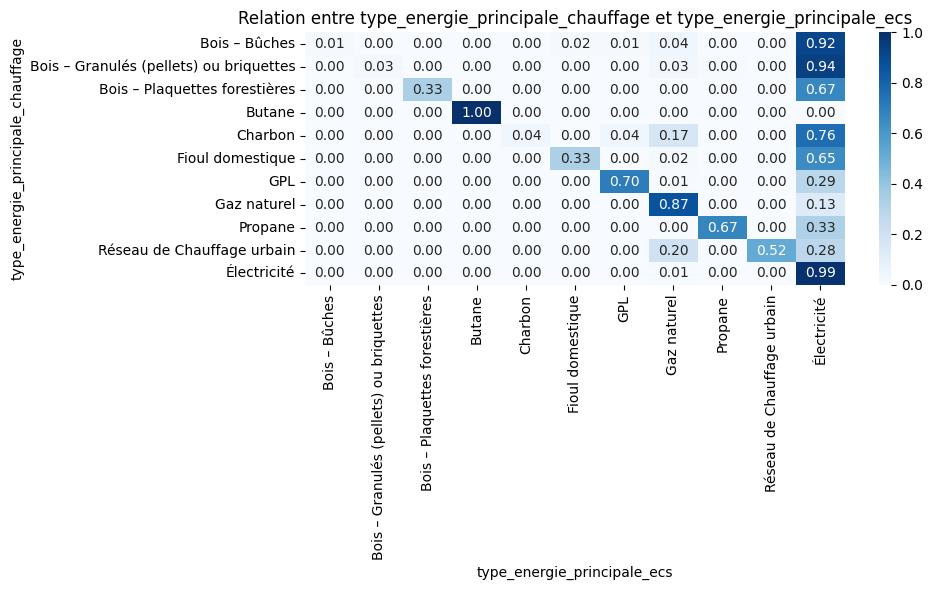

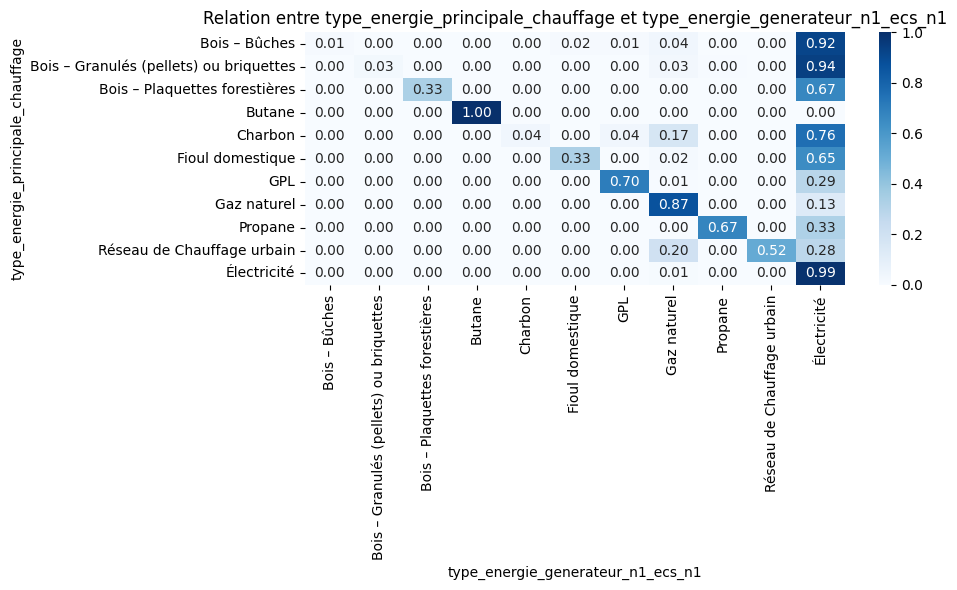

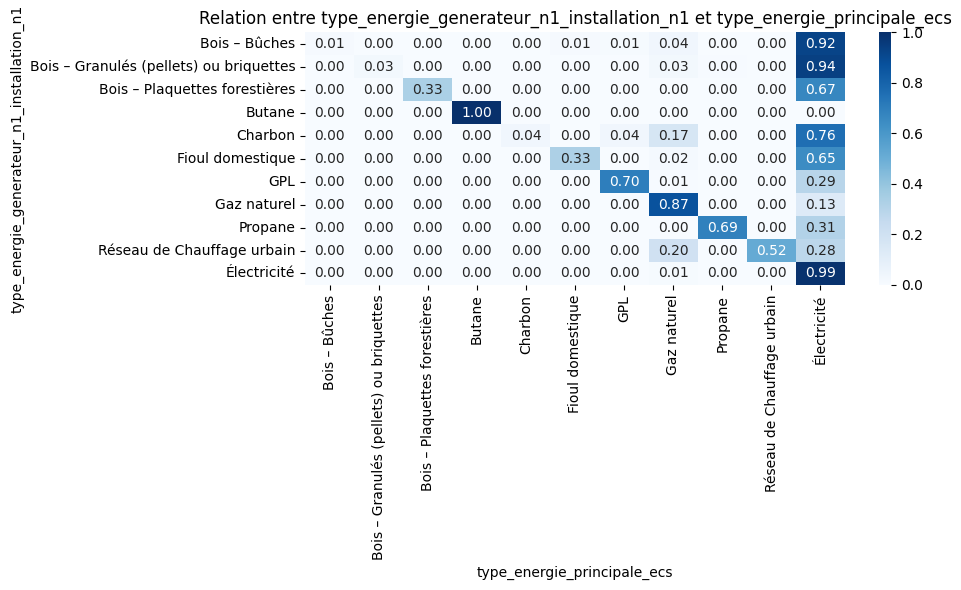

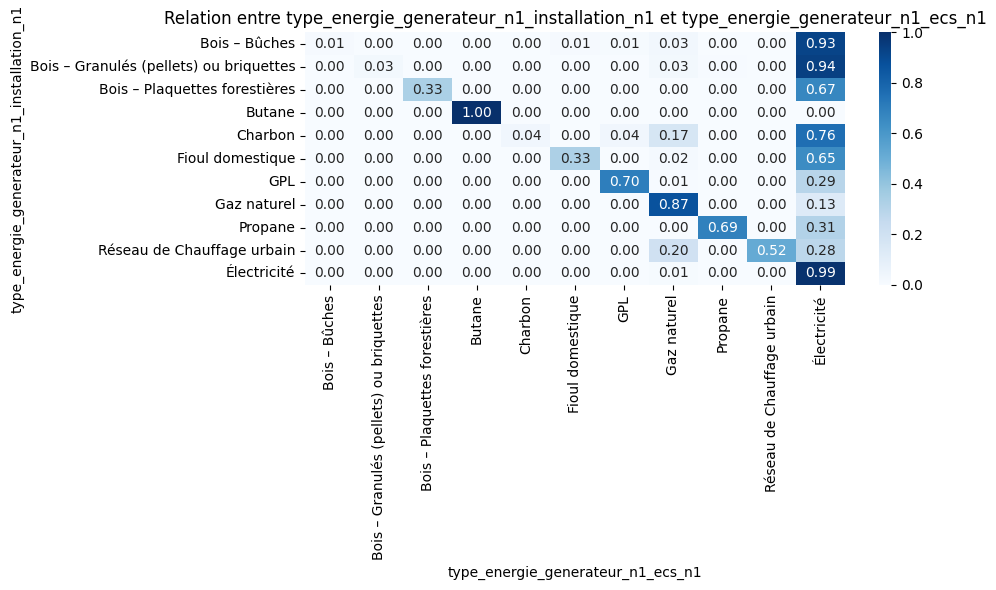

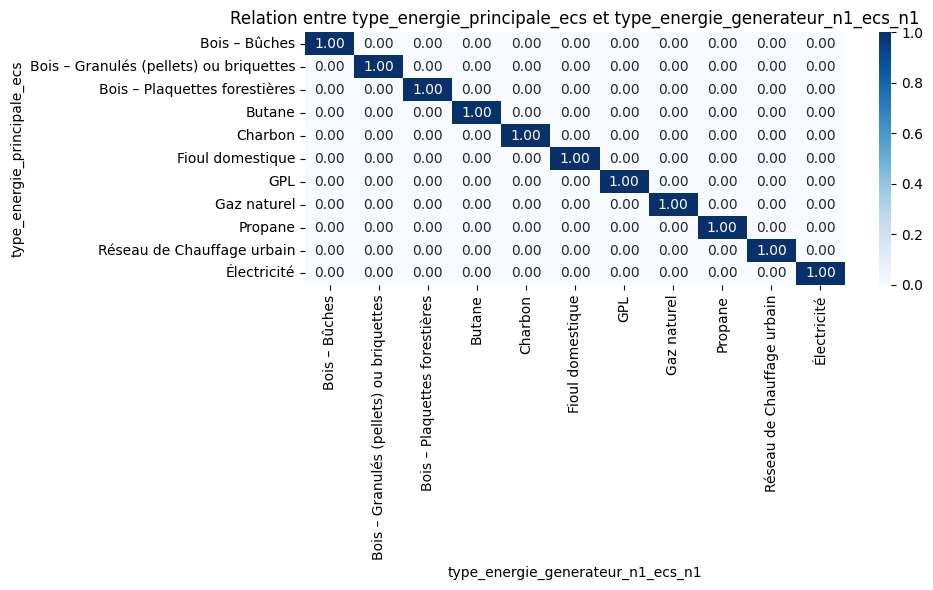

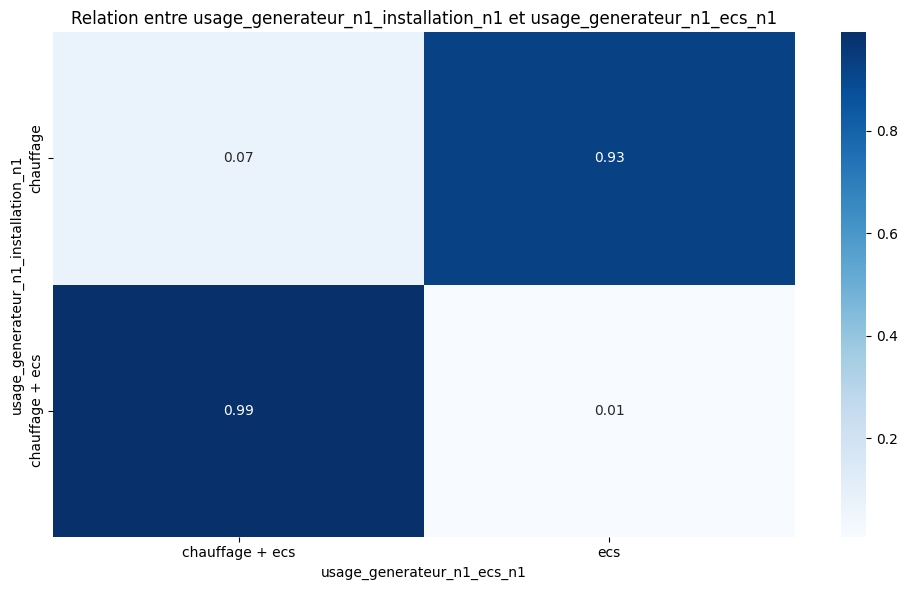

In [12]:
# Comparaison des paires de variables de même cardinalité via tableaux croisés normalisés
for k, cols in lots.items():
    if len(cols) < 2:
        continue

    for col1, col2 in itertools.combinations(cols, 2):
        table = pd.crosstab(df_data_clean[col1], df_data_clean[col2], normalize='index')

        plt.figure(figsize=(10, 6))
        sns.heatmap(table, annot=True, fmt=".2f", cmap="Blues")
        plt.title(f"Relation entre {col1} et {col2}")
        plt.xlabel(col2)
        plt.ylabel(col1)
        plt.tight_layout()
        plt.show()

**Interprétation :**

- **Forte corrélation diagonale** → les paires suivantes encodent quasiment la même information (« à chaque fois que X = A, alors Y = B ») et l'une des deux variables peut être supprimée :
  - `type_batiment` / `methode_application_dpe`
  - `type_energie_principale_chauffage` / `type_energie_generateur_n1_installation_n1`
  - `type_energie_principale_ecs` / `type_energie_generateur_n1_ecs_n1`
  - `usage_generateur_n1_installation_n1` / `usage_generateur_n1_ecs_n1`

- **Forte corrélation hors diagonale** → les paires suivantes sont proches mais apportent un complément d'information qualitative ; elles sont conservées :
  - `configuration_installation_ecs_n1` / `type_batiment`
  - `type_installation_ecs_n1` / `configuration_installation_ecs_n1`
  - `methode_application_dpe` / `type_installation_solaire_n1`
  - `classe_inertie_batiment` / `type_installation_solaire_n1`
  - `qualite_isolation_enveloppe` / `type_installation_solaire_n1`
  - `qualite_isolation_murs` / `type_installation_solaire_n1`
  - `qualite_isolation_menuiseries` / `type_installation_solaire_n1`
  - `qualite_isolation_plancher_bas` / `type_installation_solaire_n1`
  - `type_installation_chauffage_n1` / `type_installation_solaire_n1`

In [13]:
# Variables supprimées pour redondance (corrélation diagonale forte)
suppr_redondance = [
    "methode_application_dpe",
    "type_energie_generateur_n1_installation_n1",
    "type_energie_generateur_n1_ecs_n1",
    "usage_generateur_n1_ecs_n1",
]

### 3.2 Agrégation des variables catégorielles

Certaines variables comportent de nombreuses modalités peu fréquentes. On les regroupe en catégories plus larges et cohérentes, en s'appuyant sur la répartition de l'étiquette DPE par modalité (tableau croisé) et un clustering hiérarchique pour identifier les modalités similaires.

#### 3.2.1 Période de construction

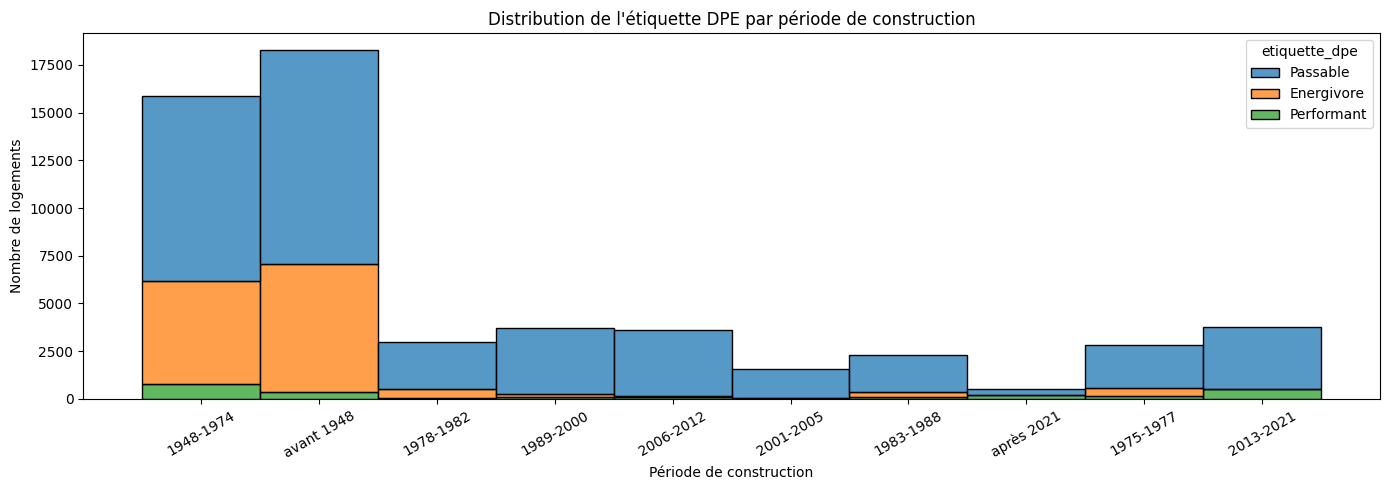

In [14]:
plt.figure(figsize=(14, 5))
sns.histplot(data=df_data_clean, x="periode_construction", hue="etiquette_dpe", multiple="stack")
plt.title("Distribution de l'étiquette DPE par période de construction")
plt.xlabel("Période de construction")
plt.ylabel("Nombre de logements")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [15]:
tab_periode = pd.crosstab(
    df_data_clean["periode_construction"],
    df_data_clean["etiquette_dpe"],
    normalize="index"
)
tab_periode.round(3)

etiquette_dpe,Energivore,Passable,Performant
periode_construction,,,
1948-1974,0.341,0.612,0.047
1975-1977,0.156,0.798,0.046
1978-1982,0.145,0.832,0.024
1983-1988,0.111,0.854,0.035
1989-2000,0.046,0.930,0.024
2001-2005,0.021,0.965,0.014
2006-2012,0.006,0.966,0.028
2013-2021,0.003,0.857,0.140
après 2021,0.002,0.633,0.365


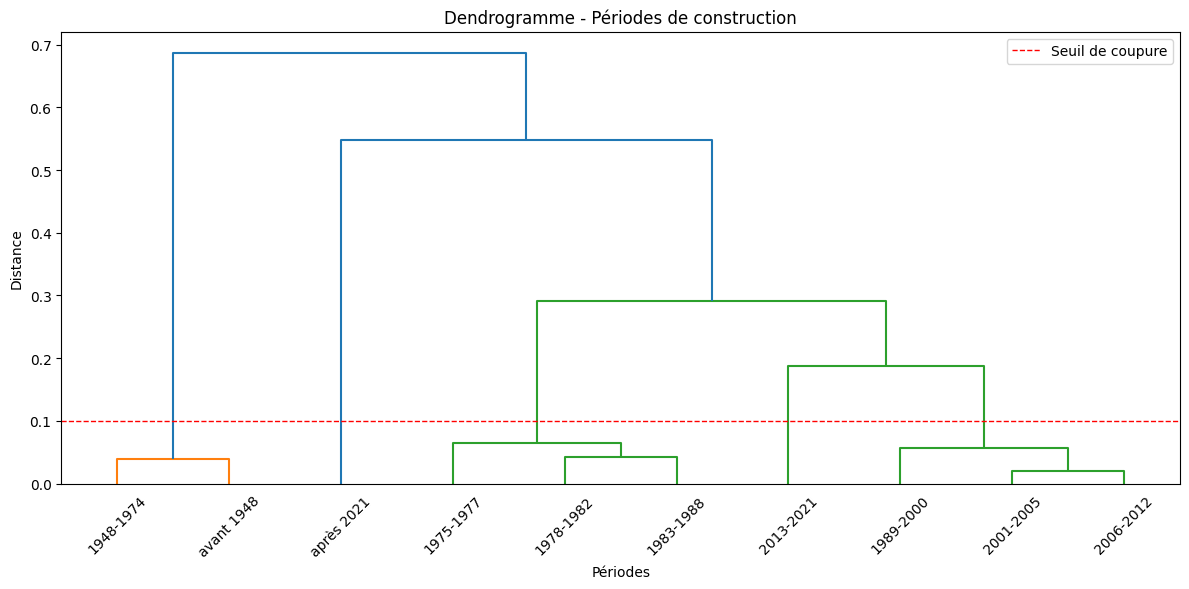

In [16]:
Z = linkage(tab_periode, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=tab_periode.index.tolist(), leaf_rotation=45, leaf_font_size=10)
plt.axhline(y=0.1, color='red', linestyle='--', linewidth=1, label='Seuil de coupure')
plt.title("Dendrogramme - Périodes de construction")
plt.xlabel("Périodes")
plt.ylabel("Distance")
plt.legend()
plt.tight_layout()
plt.show()

**Interprétation :** le dendrogramme révèle 4 à 5 groupes cohérents de périodes de construction, qui correspondent globalement aux évolutions des réglementations thermiques (avant 1948, 1948-1988, 1989-2012, après 2012). Ce regroupement réduit la cardinalité de 10 à 4 modalités tout en conservant le pouvoir discriminant sur l'étiquette DPE.

#### 3.2.2 Configuration de l'installation de chauffage

C:\Users\berul\AppData\Local\Temp\ipykernel_136668\2708534062.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


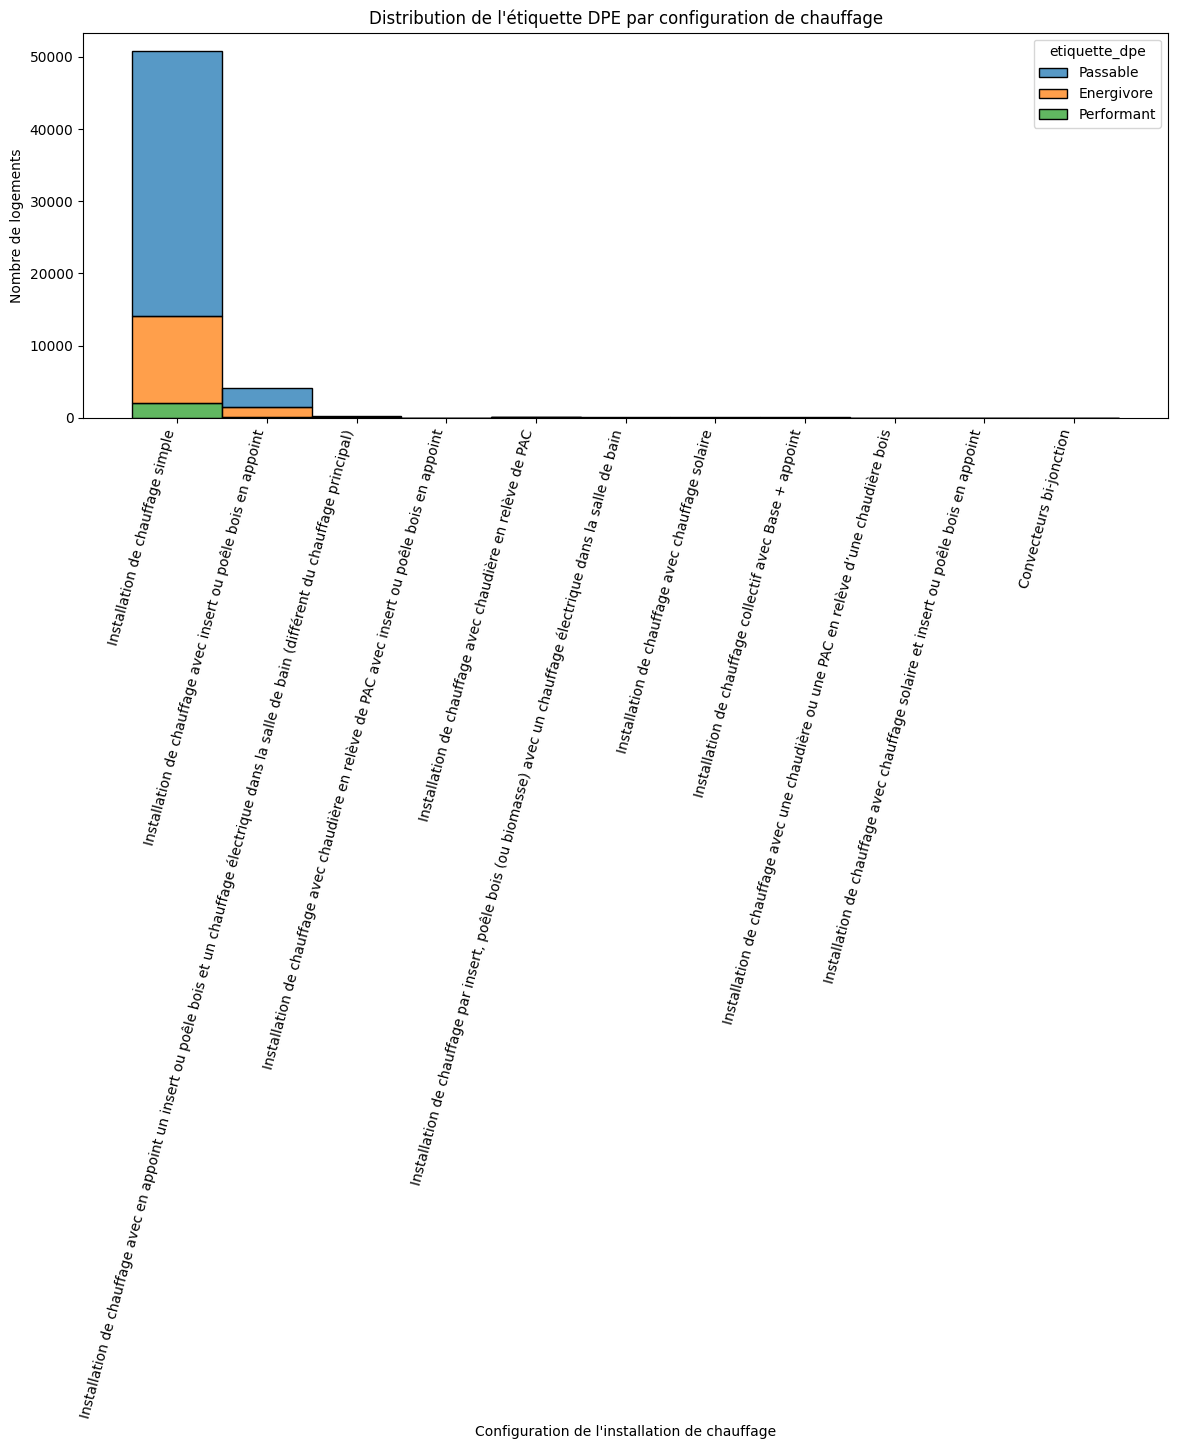

In [17]:
plt.figure(figsize=(14, 5))
sns.histplot(data=df_data_clean, x="configuration_installation_chauffage_n1", hue="etiquette_dpe", multiple="stack")
plt.title("Distribution de l'étiquette DPE par configuration de chauffage")
plt.xlabel("Configuration de l'installation de chauffage")
plt.ylabel("Nombre de logements")
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

In [18]:
tab_conf_install = pd.crosstab(
    df_data_clean["configuration_installation_chauffage_n1"],
    df_data_clean["etiquette_dpe"],
    normalize="index"
)
tab_conf_install.round(3)

etiquette_dpe,Energivore,Passable,Performant
configuration_installation_chauffage_n1,,,
Convecteurs bi-jonction,0.500,0.500,0.000
Installation de chauffage avec chaudière en relève de PAC,0.036,0.509,0.455
Installation de chauffage avec chaudière en relève de PAC avec insert ou poêle bois en appoint,0.045,0.773,0.182
Installation de chauffage avec chauffage solaire,0.062,0.281,0.656
Installation de chauffage avec chauffage solaire et insert ou poêle bois en appoint,0.000,0.857,0.143
Installation de chauffage avec en appoint un insert ou poêle bois et un chauffage électrique dans la salle de bain (différent du chauffage principal),0.274,0.673,0.054
Installation de chauffage avec insert ou poêle bois en appoint,0.343,0.624,0.033
Installation de chauffage avec une chaudière ou une PAC en relève d’une chaudière bois,0.667,0.222,0.111
Installation de chauffage collectif avec Base + appoint,0.302,0.674,0.023


C:\Users\berul\AppData\Local\Temp\ipykernel_136668\4077658091.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


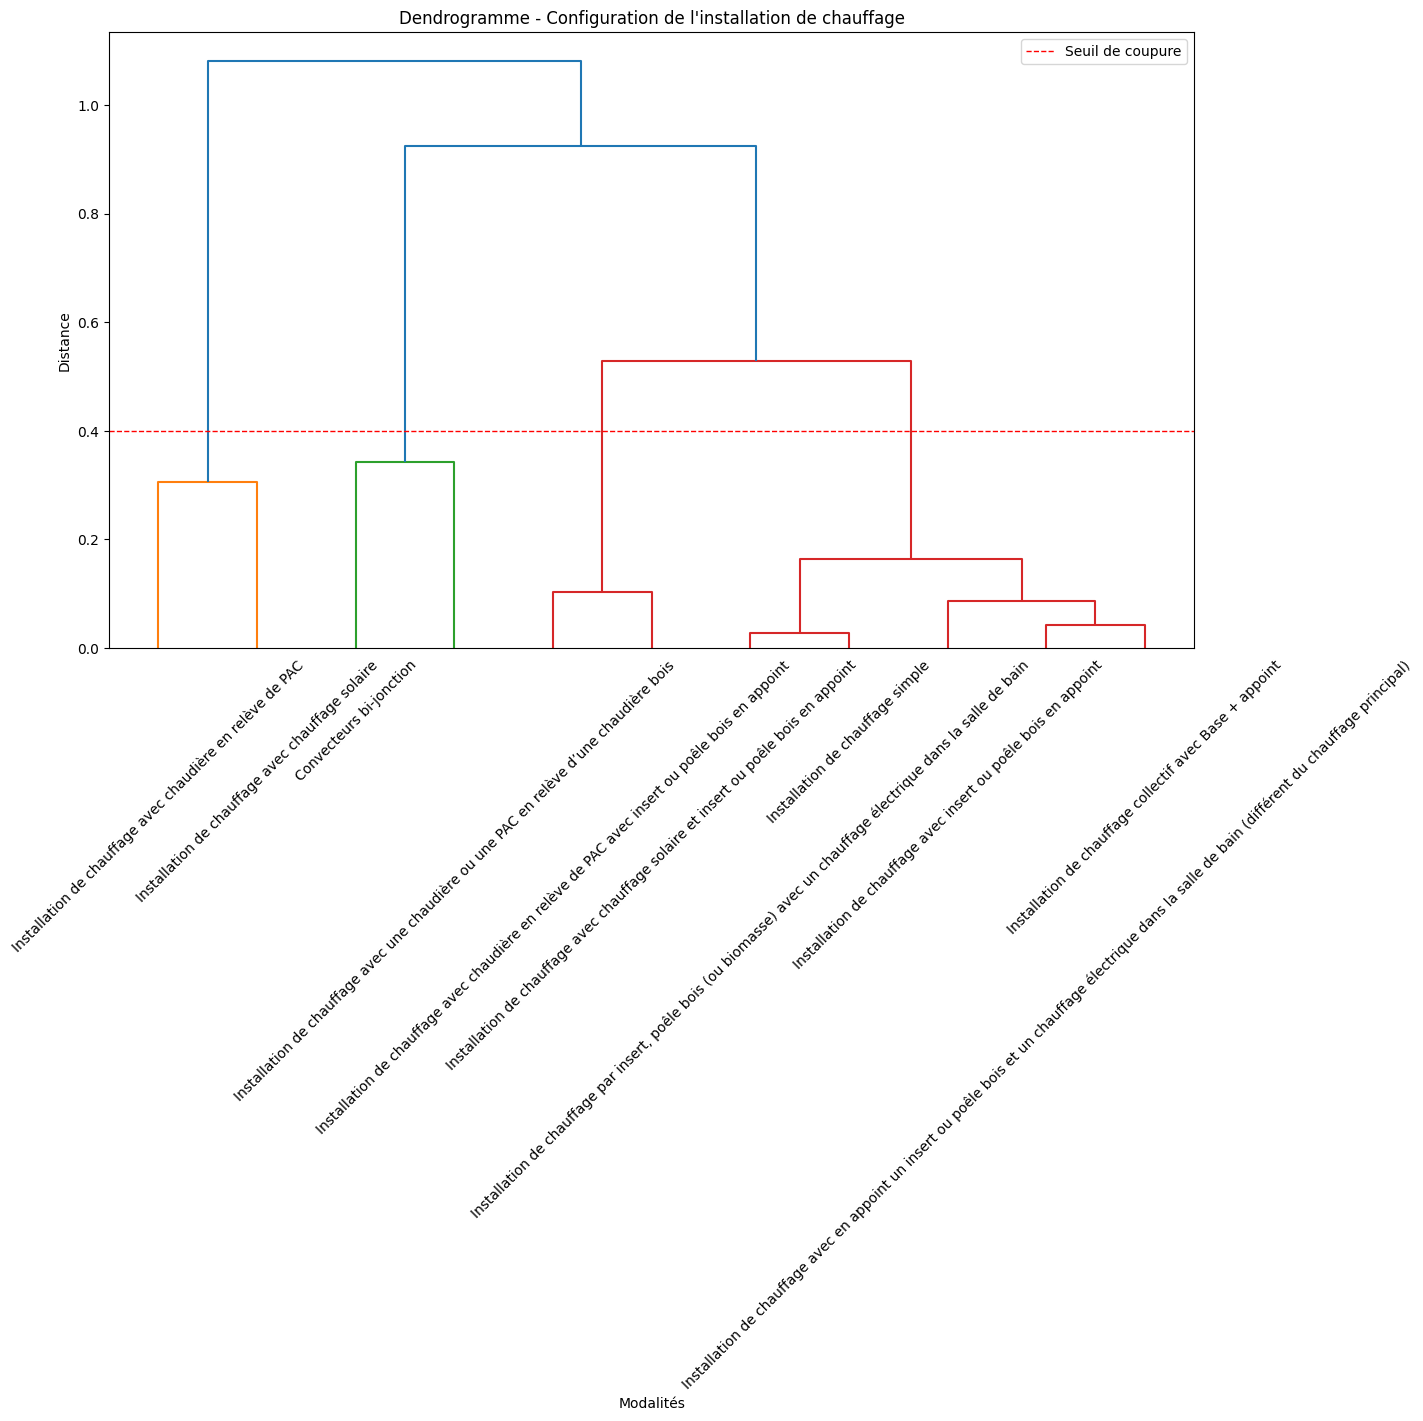

In [19]:
Z_conf_install = linkage(tab_conf_install, method='ward')

plt.figure(figsize=(14, 8))
dendrogram(Z_conf_install, labels=tab_conf_install.index.tolist(), leaf_rotation=45, leaf_font_size=10)
plt.axhline(y=0.4, color='red', linestyle='--', linewidth=1, label='Seuil de coupure')
plt.title("Dendrogramme - Configuration de l'installation de chauffage")
plt.xlabel("Modalités")
plt.ylabel("Distance")
plt.legend()
plt.tight_layout()
plt.show()

**Interprétation :** le clustering met en évidence 4 groupes selon le niveau de performance du système de chauffage. On définit ainsi le mapping suivant :

| Modalités d'origine | Catégorie |
|---|---|
| Installation simple, insert/poêle bois en appoint, collectif Base + appoint, ... | `standard` |
| Chauffage solaire + insert/poêle bois, chaudière/PAC en relève de chaudière bois | `intermediaire` |
| Chaudière en relève de PAC (avec ou sans appoint bois), chauffage solaire | `performant` |
| Convecteurs bi-jonction | `rare` |

#### 3.2.3 Type d'énergie principale de chauffage

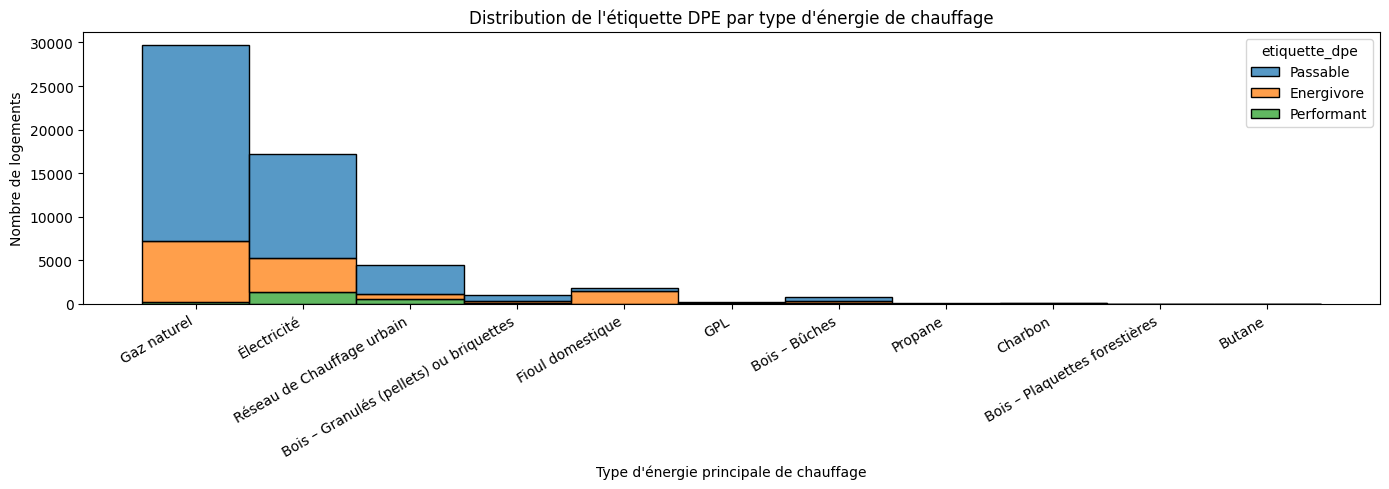

In [20]:
plt.figure(figsize=(14, 5))
sns.histplot(data=df_data_clean, x="type_energie_principale_chauffage", hue="etiquette_dpe", multiple="stack")
plt.title("Distribution de l'étiquette DPE par type d'énergie de chauffage")
plt.xlabel("Type d'énergie principale de chauffage")
plt.ylabel("Nombre de logements")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [21]:
tab_en_prin_chauf = pd.crosstab(
    df_data_clean["type_energie_principale_chauffage"],
    df_data_clean["etiquette_dpe"],
    normalize="index"
)
tab_en_prin_chauf.round(3)

etiquette_dpe,Energivore,Passable,Performant
type_energie_principale_chauffage,,,
Bois – Bûches,0.352,0.569,0.080
Bois – Granulés (pellets) ou briquettes,0.184,0.717,0.099
Bois – Plaquettes forestières,0.667,0.333,0.000
Butane,1.000,0.000,0.000
Charbon,0.981,0.019,0.000
Fioul domestique,0.785,0.214,0.001
GPL,0.426,0.568,0.006
Gaz naturel,0.234,0.757,0.008
Propane,0.469,0.490,0.041


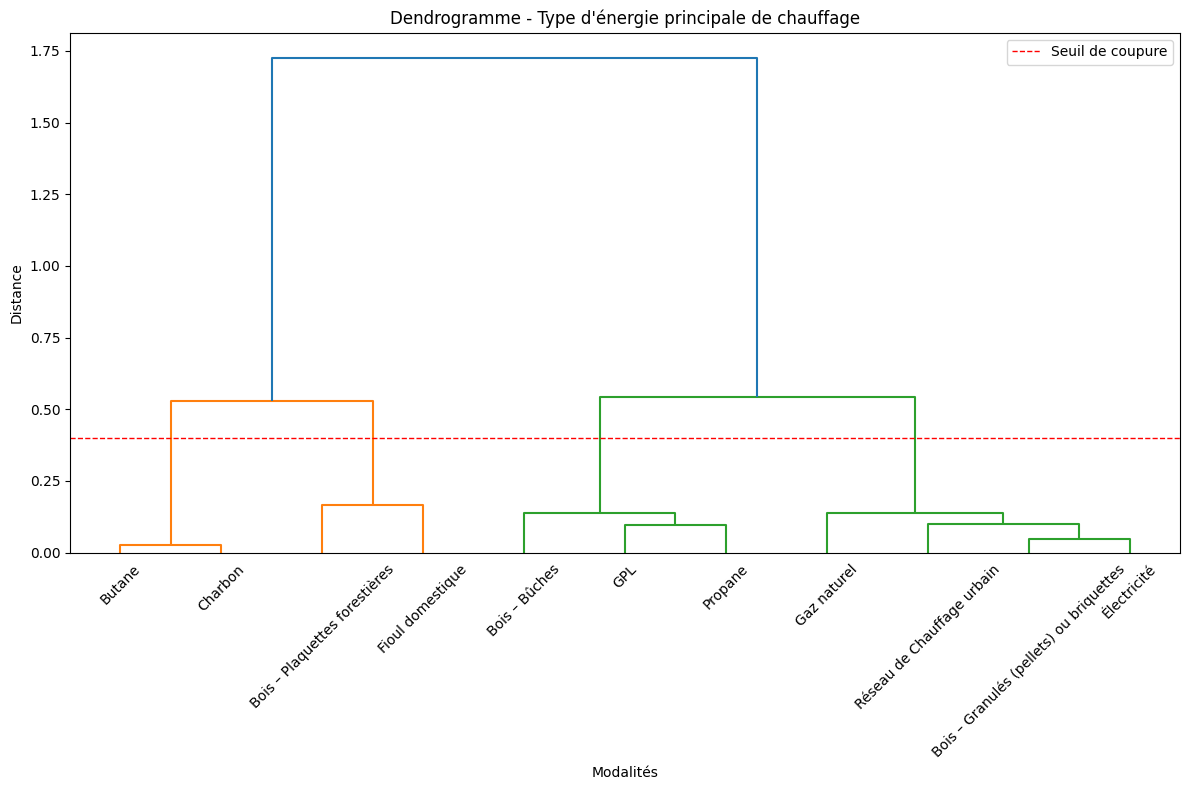

In [22]:
Z_en_prin_chauf = linkage(tab_en_prin_chauf, method='ward')

plt.figure(figsize=(12, 8))
dendrogram(Z_en_prin_chauf, labels=tab_en_prin_chauf.index.tolist(), leaf_rotation=45, leaf_font_size=10)
plt.axhline(y=0.4, color='red', linestyle='--', linewidth=1, label='Seuil de coupure')
plt.title("Dendrogramme - Type d'énergie principale de chauffage")
plt.xlabel("Modalités")
plt.ylabel("Distance")
plt.legend()
plt.tight_layout()
plt.show()

**Interprétation :** les énergies se regroupent naturellement par famille (bois, gaz liquéfiés) selon leur profil DPE. Le bois performant (granulés) se distingue du bois traditionnel (bûches, plaquettes), et les gaz liquéfiés (GPL, propane, butane) sont fusionnés en une seule catégorie. Les autres énergies (gaz naturel, électricité, fioul, réseau urbain, charbon) sont conservées telles quelles.

### 3.3 Construction des mappings d'agrégation

In [23]:
mapping_periode_construction = {
    'avant 1948': 'ancien',
    '1948-1974': 'ancien',

    '1975-1977': 'transition',
    '1978-1982': 'transition',
    '1983-1988': 'transition',

    '1989-2000': 'moderne',
    '2001-2005': 'moderne',
    '2006-2012': 'moderne',

    '2013-2021': 'recent',
    'après 2021': 'tres_recent',
}

mapping_configuration_installation_chauffage_n1 = {
    'Installation de chauffage simple': 'standard',
    'Installation de chauffage avec insert ou poêle bois en appoint': 'standard',
    'Installation de chauffage collectif avec Base + appoint': 'standard',
    'Installation de chauffage par insert, poêle bois (ou biomasse) avec un chauffage électrique dans la salle de bain': 'standard',
    'Installation de chauffage avec en appoint un insert ou poêle bois et un chauffage électrique dans la salle de bain (différent du chauffage principal)': 'standard',

    'Installation de chauffage avec chauffage solaire et insert ou poêle bois en appoint': 'intermediaire',
    'Installation de chauffage avec une chaudière ou une PAC en relève d\'une chaudière bois': 'intermediaire',

    'Installation de chauffage avec chaudière en relève de PAC': 'performant',
    'Installation de chauffage avec chaudière en relève de PAC avec insert ou poêle bois en appoint': 'performant',
    'Installation de chauffage avec chauffage solaire': 'performant',

    'Convecteurs bi-jonction': 'rare',
}

mapping_energie = {
    # Bois
    'Bois – Granulés (pellets) ou briquettes': 'Bois performant',
    'Bois – Bûches': 'Bois traditionnel',
    'Bois – Plaquettes forestières': 'Bois traditionnel',

    # Gaz liquéfiés
    'GPL': 'Gaz liquéfié',
    'Propane': 'Gaz liquéfié',
    'Butane': 'Gaz liquéfié',

    # Conservés tels quels
    'Gaz naturel': 'Gaz naturel',
    'Électricité': 'Électricité',
    'Fioul domestique': 'Fioul domestique',
    'Réseau de Chauffage urbain': 'Réseau de Chauffage urbain',
    'Charbon': 'Charbon',
}

# Le même mapping énergie s'applique au chauffage et à l'ECS
mapping_type_energie_principale_chauffage = mapping_energie
mapping_type_energie_principale_ecs = mapping_energie

list_mapping = [
    ("periode_construction", mapping_periode_construction),
    ("configuration_installation_chauffage_n1", mapping_configuration_installation_chauffage_n1),
    ("type_energie_principale_chauffage", mapping_type_energie_principale_chauffage),
    ("type_energie_principale_ecs", mapping_type_energie_principale_ecs),
]

## 4. Haute cardinalité vs basse cardinalité

Trois variables possèdent un très grand nombre de modalités :

- `type_generateur_n1_installation_n1` (≈ 130 modalités)
- `type_generateur_n1_ecs_n1` (≈ 95 modalités)
- `type_emetteur_installation_chauffage_n1` (≈ 46 modalités)

Un encodage One-Hot brut produirait plus de 270 colonnes creuses, dont la majorité aurait moins de 50 occurrences, ce qui dégraderait les performances et l'explicabilité du modèle. On regroupe donc les modalités rares (< 1 % de l'effectif) sous une catégorie `Autre`.

In [24]:
def regroup_rare_modalities(df, col, threshold_pct=1.0, label_rare='Autre'):
    """Regroupe les modalités représentant moins de threshold_pct % de l'effectif sous label_rare."""
    total = len(df)
    counts = df[col].value_counts()
    threshold_n = total * threshold_pct / 100

    rare = counts[counts < threshold_n].index.tolist()
    df_out = df.copy()
    df_out[col] = df_out[col].apply(lambda x: label_rare if x in rare else x)

    return df_out, len(rare), df_out[col].nunique()


high_card_cols = [
    col for col in df_data_clean.select_dtypes(include='object').columns
    if col != "etiquette_dpe" and df_data_clean[col].nunique() > 15
]

print(f"Variables à haute cardinalité (> 15 modalités) :")
print(f"{'Variable':<55} {'Avant':>8} {'Après':>8}  Modalités rares regroupées")
print("─" * 95)

for col in high_card_cols:
    n_before = df_data_clean[col].nunique()
    df_data_clean, n_rare, n_after = regroup_rare_modalities(df_data_clean, col, threshold_pct=1.0)
    print(f"{col:<55} {n_before:>8} {n_after:>8}  ({n_rare} modalités < 1% → 'Autre')")

print(f"\n✓ Dataset après traitement : {df_data_clean.shape[0]:,} lignes × {df_data_clean.shape[1]} colonnes")

C:\Users\berul\AppData\Local\Temp\ipykernel_136668\3867451583.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col for col in df_data_clean.select_dtypes(include='object').columns


Variables à haute cardinalité (> 15 modalités) :
Variable                                                   Avant    Après  Modalités rares regroupées
───────────────────────────────────────────────────────────────────────────────────────────────
type_generateur_n1_installation_n1                           130       16  (115 modalités < 1% → 'Autre')
type_emetteur_installation_chauffage_n1                       46       17  (30 modalités < 1% → 'Autre')
type_generateur_n1_ecs_n1                                     95       15  (81 modalités < 1% → 'Autre')

✓ Dataset après traitement : 55,357 lignes × 29 colonnes


**Interprétation :** le regroupement des modalités rares réduit fortement la dimensionnalité après encodage, améliore la généralisation du modèle et évite les problèmes de modalités jamais vues lors de la prédiction sur de nouvelles données.

## 5. Application des transformations et export

In [25]:
# Suppression des colonnes redondantes identifiées en 3.1
df_data_clean_suppr = df_data_clean.drop(columns=suppr_redondance)

# Application des mappings d'agrégation définis en 3.3
for col, mapping_dict in list_mapping:
    df_data_clean_suppr[col] = df_data_clean_suppr[col].map(mapping_dict)

df_data_clean_mapp = df_data_clean_suppr.copy()
df_data_clean_mapp.head()

,etiquette_dpe,zone_climatique,classe_altitude,type_batiment,periode_construction,hauteur_sous_plafond,classe_inertie_batiment,qualite_isolation_enveloppe,qualite_isolation_murs,qualite_isolation_menuiseries,...,type_emetteur_installation_chauffage_n1,usage_generateur_n1_installation_n1,type_installation_ecs_n1,configuration_installation_ecs_n1,type_generateur_n1_ecs_n1,type_energie_principale_ecs,volume_stockage_generateur_n1_ecs_n1,ventilation_posterieure_2012,type_installation_solaire_n1,production_electricite_pv_kwhep_par_an
0,Passable,H1a,inférieur à 400m,maison,ancien,2.5,Lourde,très bonne,très bonne,bonne,...,Autre,chauffage + ecs,installation individuelle,Un seul système d'ECS sans solaire,Chaudière gaz à condensation après 2015,Gaz naturel,0.0,1,Non affecté,0.0
1,Energivore,H1a,inférieur à 400m,maison,ancien,2.6,Lourde,insuffisante,insuffisante,moyenne,...,Radiateur bitube avec robinet thermostatique s...,chauffage + ecs,installation individuelle,Un seul système d'ECS sans solaire,Chaudière gaz à condensation 2001-2015,Gaz naturel,0.0,0,Non affecté,0.0
2,Passable,H1a,inférieur à 400m,appartement,transition,2.5,Moyenne,très bonne,insuffisante,très bonne,...,"Panneau rayonnant NFC, NF** et NF***",chauffage,installation individuelle,Un seul système d'ECS sans solaire,CET sur air ambiant (sur local non chauffé) ap...,Électricité,150.0,1,Non affecté,0.0
3,Energivore,H1a,inférieur à 400m,maison,ancien,2.5,Légère,moyenne,moyenne,moyenne,...,"radiateur électrique NFC, NF** et NF***",chauffage,installation individuelle,Un seul système d'ECS sans solaire,Ballon électrique à accumulation vertical Caté...,Électricité,150.0,0,Non affecté,0.0
4,Passable,H1a,inférieur à 400m,maison,moderne,2.5,Moyenne,moyenne,moyenne,moyenne,...,Radiateur monotube avec robinet thermostatique...,chauffage + ecs,installation individuelle,Un seul système d'ECS sans solaire,Chaudière gaz à condensation après 2015,Gaz naturel,0.0,0,Non affecté,0.0


In [26]:
df_data_clean_mapp.to_excel('data_for_processing_final.xlsx', index=False)
print(f"Export terminé : {df_data_clean_mapp.shape[0]:,} lignes × {df_data_clean_mapp.shape[1]} colonnes")

Export terminé : 55,357 lignes × 25 colonnes


**Interprétation finale :** le jeu de données est désormais nettoyé (variables non pertinentes et fortement manquantes supprimées), débarrassé des redondances, et les variables catégorielles à forte cardinalité ont été regroupées de façon cohérente avec le pouvoir discriminant sur l'étiquette DPE. Il est prêt pour les étapes d'encodage et de modélisation.